# Supplementary Figs. 2–5 — myeloid (TETRIS-seq) panel design

Lollipop plots of mutation distribution along each gene on the TETRIS-seq myeloid panel:
clonal-haematopoiesis variants from nine published CH studies (top) and AML variants from COSMIC
(bottom), coloured by mutation type, with the exon structure and targeted panel regions annotated.
One plot per gene (34 genes across Supplementary Figs. 2–5).

**Exon coordinates are fetched programmatically** from Ensembl (via the REST API). The transcript used for each gene
is the one reported in the manuscript (**Supplementary Table 1**; `GENE_TRANSCRIPTS`), so the exon
structure matches the paper. Results are cached under `Data_files/ensembl_exon_cache/` (hg19) so the
lookups run once per gene.

## Requirements & data availability

- Ensembl REST API and **Biopython** are required for the exon fetching.

| folder | contents | location |
|---|---|---|
| `CH_studies/` | CH variant counts aggregated from nine published CH studies | Data_files |
| `COSMIC_AML_data/` | per-gene AML variant counts from COSMIC (check COSMIC licence before redistribution) | Data_files |
| `ensembl_exon_cache/` | cached Ensembl exon lookups (created on first run) | Data_files |


In [1]:
# imported packages
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import pandas as pd
import csv
import requests
from Bio.Seq import Seq

In [2]:
# Lists of colors for plots
c0 = (0.76, 0.76, 0.76) #C2C2C2
c1 = (1.00, 0.18, 0.33); #FF2E54 - 
c2 = (1.00, 0.23, 0.19); #FF3A30 
c3 = (1.00, 0.58, 0.00); #FF9400 -
c4 = (1.00, 0.80, 0.00); #FFCC00 - 
c5 = (0.30, 0.85, 0.39); #4DD964 -
c6 = (0.35, 0.78, 0.98); #5AC7FA -
c7 = (0.20, 0.67, 0.86); #33ABDC
c8 = (0.00, 0.48, 1.00); #007AFF - 
c9 = (0.35, 0.34, 0.84); #5957D6 - 
c10 = (0.00, 0.31, 0.57); #004F91 - 
c11 = (0.12, 0.29, 0.69); #1F4AB0
c12 = (0.17, 0.17, 0.42); #2B2B6B - 
c13 = (1.00, 1.00, 1.00); #FFFFFF
c14 = (0.77, 0.04, 0.00); #C40A00

In [3]:
#define the colors from colorbrewer2
orange1 = '#feedde'
orange2 = '#fdbe85'
orange3 = '#fd8d3c'
orange4 = '#e6550d'
orange5 = '#a63603'
blue1 = '#eff3ff'
blue2 = '#bdd7e7'
blue3 = '#6baed6'
blue4 = '#3182bd'
blue5 = '#08519c'
green1 = '#edf8e9'
green2 = '#bae4b3'
green3 = '#74c476'
green4 = '#31a354'
green5 = '#006d2c'
grey1 = '#f7f7f7'
grey2 = '#cccccc'
grey3 = '#969696'
grey4 = '#636363'
grey5 = '#252525'
purple1 = '#f2f0f7'
purple2 = '#cbc9e2'
purple3 = '#9e9ac8'
purple4 = '#756bb1'
purple5 = '#54278f'
red1 = '#fee5d9'
red2 = '#fcae91'
red3 = '#fb6a4a'
red4 = '#de2d26'
red5 = '#a50f15'

In [4]:
eblue1 = '#fff7fb'
eblue2 = '#ece7f2'
eblue3 = '#d0d1e6'
eblue4 = '#a6bddb'
eblue5 = '#74a9cf'
eblue6 = '#3690c0'

In [5]:
#Assigning colours to types of variants
Sub_Mis = c1
Sub_Non = c9
Sub_Syn = c5
Ins_Frame = c3
Del_Frame = c4
Com_Frame = orange3
Frame = orange4
Ins = purple3
Unk = red1
Ins_Inf = c6
Del_Inf = c8
DFI = green5
Com_Ins_Inf = c11
Com_Del_Inf = c12
Com_Com_Sub = purple2
Splice_Site = grey2
Splice_Acc_Var = grey3
Splice_Don_Var = grey4
Intron = grey5
Del = blue1

# Functions and colour lists

In [6]:
def CH_mutations_dictionary(gene_of_interest):

    with open('Data_files/CH_studies/all_studies_variants_counts.csv') as csvfile:
        read_reader = csv.reader(csvfile)  #csv.reader returns a reader object which will iterate over lines in the csvfile
        row_count=0
        mutations_CH={}

        for row in read_reader:
    #         print(row)
            if row_count>0:
                gene = row[0]
                variant = row[1]
                AA_position = int(row[2])
                variant_type = row[3]
                jaiswal = int(row[4])
                genovese = int(row[5])
                zink = int(row[6])
                coombs = int(row[7])
                desai = int(row[8])
                acuna = int(row[9])
                mckerrel = int(row[10])
                young2016 = int(row[11])
                young2019 = int(row[12])
                if gene == gene_of_interest:
                    mutation_count = jaiswal + genovese + zink + coombs + desai + acuna + mckerrel + young2016 + young2019
                    if variant_type in mutations_CH.keys():
                        mutations_CH[variant_type][(variant, AA_position)]=mutation_count
                    else:
                        mutations_CH[variant_type]={}
                        mutations_CH[variant_type][(variant, AA_position)]=mutation_count

            row_count+=1
        
    return mutations_CH

In [7]:
def CH_mutations_dictionary_combining_variants_at_position(gene_of_interest):

    with open('Data_files/CH_studies/all_studies_variants_counts.csv') as csvfile:
        read_reader = csv.reader(csvfile)  #csv.reader returns a reader object which will iterate over lines in the csvfile
        row_count=0
        mutations_CH={}

        for row in read_reader:
    #         print(row)
            if row_count>0:
                gene = row[0]
                variant = row[1]
                AA_position = int(row[2])
                variant_type = row[3]
                jaiswal = int(row[4])
                genovese = int(row[5])
                zink = int(row[6])
                coombs = int(row[7])
                desai = int(row[8])
                acuna = int(row[9])
                mckerrel = int(row[10])
                young2016 = int(row[11])
                young2019 = int(row[12])
                if variant_type == 'Substitution_Missense':
                    variant_type = 'Missense'
                if variant_type in ['Substitution_Nonsense', 'Indel Nonsense', 'Duplication Nonsense', 'DuplicationNonsense']:
                    variant_type = 'Nonsense'
                if variant_type == 'Substitution_Synonymous':
                    variant_type = 'Synonymous'
                if variant_type == 'Insertion_Frameshift':
                    variant_type = 'Frameshift Insertion'
                if variant_type == 'Insertion Frameshift':
                    variant_type = 'Frameshift Insertion'
                if variant_type == 'Frameshift':
                    variant_type = 'Frameshift'
                if variant_type == 'Insertion_Inframe':
                    variant_type = 'Inframe Insertion'
                if variant_type == 'Insertion Inframe':
                    variant_type = 'Inframe Insertion'
                if variant_type == 'Deletion_Inframe':
                    variant_type = 'Inframe Deletion'
                if variant_type == 'Deletion Inframe':
                    variant_type = 'Inframe Deletion'
                if variant_type == 'Deletion_Frameshift':
                    variant_type = 'Frameshift Deletion'
                if variant_type == 'Deletion Frameshift':
                    variant_type = 'Frameshift Deletion'
                if variant_type == 'Complex_Frameshift':
                    variant_type = 'Frameshift (Complex)'
                if variant_type == 'Complex Frameshift':
                    variant_type = 'Frameshift (Complex)'
                if variant_type == 'Frameshift Duplication':
                    variant_type = 'Frameshift Insertion'
                if variant_type == 'Complex_Deletion_Inframe':
                    variant_type = 'Inframe Deletion (Complex)'
                if variant_type == 'Complex_Insertion_Inframe':
                    variant_type = 'Inframe Insertion (Complex)'
                if variant_type in ['Complex_Compound_Substitution']:
                    variant_type = 'Complex'
                if gene == gene_of_interest:
                    mutation_count = jaiswal + genovese + zink + coombs + desai + acuna + mckerrel + young2016 + young2019
                    if variant_type in mutations_CH.keys():
                        if AA_position in mutations_CH[variant_type].keys():
                            mutations_CH[variant_type][AA_position]+=mutation_count
                        else:
                            mutations_CH[variant_type][AA_position]=mutation_count
                    else:
                        mutations_CH[variant_type]={}
                        mutations_CH[variant_type][AA_position]=mutation_count

            row_count+=1
        
    return mutations_CH

In [8]:
def AML_mutations_dictionary_combining_variants_at_position(gene_of_interest, csv_file):

    with open(csv_file) as csvfile:
        read_reader = csv.reader(csvfile)  #csv.reader returns a reader object which will iterate over lines in the csvfile
        row_count=0
        mutations_AML={}

        for row in read_reader:
    #         print(row)
            if row_count>0:
                gene = row[0]
                variant = row[2]
                AA_position = int(row[3])
                mutation_count = int(row[4])
                variant_type = row[5]
                if variant_type == 'Substitution_Missense':
                    variant_type = 'Missense'
                if variant_type in ['Substitution_Nonsense', 'Indel Nonsense', 'Duplication Nonsense']:
                    variant_type = 'Nonsense'
                if variant_type == 'Substitution_Synonymous':
                    variant_type = 'Synonymous'
                if variant_type == 'Insertion_Frameshift':
                    variant_type = 'Frameshift Insertion'
                if variant_type == 'Insertion Frameshift':
                    variant_type = 'Frameshift Insertion'
                if variant_type == 'Frameshift':
                    variant_type = 'Frameshift'
                if variant_type == 'Insertion_Inframe':
                    variant_type = 'Inframe Insertion'
                if variant_type == 'Insertion Inframe':
                    variant_type = 'Inframe Insertion'
                if variant_type == 'Deletion_Inframe':
                    variant_type = 'Inframe Deletion'
                if variant_type == 'Deletion Inframe':
                    variant_type = 'Inframe Deletion'
                if variant_type == 'Deletion_Frameshift':
                    variant_type = 'Frameshift Deletion'
                if variant_type == 'Deletion Frameshift':
                    variant_type = 'Frameshift Deletion'
                if variant_type == 'Complex_Frameshift':
                    variant_type = 'Frameshift (Complex)'
                if variant_type == 'Frameshift Duplication':
                    variant_type = 'Frameshift Insertion'
                if variant_type == 'Complex Frameshift':
                    variant_type = 'Frameshift (Complex)'
                if variant_type == 'Complex_Deletion_Inframe':
                    variant_type = 'Inframe Deletion (Complex)'
                if variant_type == 'Complex_Insertion_Inframe':
                    variant_type = 'Inframe Insertion (Complex)'
                if variant_type in ['Complex_Compound_Substitution']:
                    variant_type = 'Complex'
                if variant_type in mutations_AML.keys():
                    if AA_position in mutations_AML[variant_type].keys():
                        mutations_AML[variant_type][AA_position]+=mutation_count
                    else:
                        mutations_AML[variant_type][AA_position]=mutation_count
                else:
                    mutations_AML[variant_type]={}
                    mutations_AML[variant_type][AA_position]=mutation_count

            row_count+=1
        
    return mutations_AML

In [9]:
mutation_colors = {'Missense': c1,
                  'Nonsense': 'dodgerblue',
                  'Synonymous': c5, #'#a8ddb5'
                   'Frameshift': '#ffffcc',
                  'Frameshift Deletion': c4,
                  'Frameshift Insertion': c3,
                  'Frameshift Duplication': '#cc4c02',
                   'Frameshift (Complex)': '#662506',
                  'Inframe Deletion': '#dadaeb',
                  'Inframe Insertion': '#9e9ac8',
                   'Inframe Deletion (Complex)': '#08306b',
                   'Inframe Insertion (Complex)': '#54278f',
                   'Insertion':  'pink',
                   'Deletion':  '#ae017e',
                   'Complex': '#016c59',
                  'Indel Nonsense': purple2,
                   'Splicing':  grey4,
                   'Intronic': '#525252',
                  'Unknown': 'white',
                  'UTR3': 'black'}

In [10]:
GENE_TRANSCRIPTS = {  # canonical transcripts used in the manuscript (Supplementary Table 1)
    'ASXL1': 'ENST00000375687',
    'BCOR': 'ENST00000378444',
    'BCORL1': 'ENST00000540052',
    'CBL': 'ENST00000264033',
    'CEBPA': 'ENST00000498907',
    'CHEK2': 'ENST00000328354',
    'CSF3R': 'ENST00000373106',
    'DDX41': 'ENST00000507955',
    'DNMT3A': 'ENST00000321117',
    'EZH2': 'ENST00000320356',
    'FLT3': 'ENST00000241453',
    'GATA2': 'ENST00000487848',
    'GNAS': 'ENST00000371100',
    'GNB1': 'ENST00000378609',
    'IDH1': 'ENST00000345146',
    'IDH2': 'ENST00000330062',
    'JAK2': 'ENST00000381652',
    'KIT': 'ENST00000288135',
    'KRAS': 'ENST00000256078',
    'MPL': 'ENST00000372470',
    'NPM1': 'ENST00000296930',
    'NRAS': 'ENST00000369535',
    'PPM1D': 'ENST00000305921',
    'PTPN11': 'ENST00000351677',
    'RAD21': 'ENST00000297338',
    'RUNX1': 'ENST00000344691',
    'SF3B1': 'ENST00000335508',
    'SRSF2': 'ENST00000392485',
    'STAG2': 'ENST00000371160',
    'TET2': 'ENST00000380013',
    'TP53': 'ENST00000269305',
    'U2AF1': 'ENST00000291552',
    'WT1': 'ENST00000332351',
    'ZRSR2': 'ENST00000307771',
}

def get_canonical_transcript(gene_name, genome_version):
    """Fetch canonical transcript of a gene from Ensembl."""
    
    # Choose the correct Ensembl API server for hg38 or hg19
    if genome_version == "hg19":
        server = "https://grch37.rest.ensembl.org"  # GRCh37 (hg19)
    else:
        server = "https://rest.ensembl.org"          # GRCh38 (hg38)

    headers = {"Content-Type": "application/json"}

    # Step 1: Get gene details to find the canonical transcript
    lookup_url = f"{server}/lookup/symbol/human/{gene_name}?expand=1"
    gene_response = requests.get(lookup_url, headers=headers)

    if not gene_response.ok:
        print(f"Error fetching gene data for {gene_name} ({genome_version}): {gene_response.text}")
        return None

    gene_data = gene_response.json()
    
    # Find the canonical transcript
    canonical_transcript = None
    for transcript in gene_data.get("Transcript", []):
        if (gene_name in GENE_TRANSCRIPTS and transcript["id"].split(".")[0] == GENE_TRANSCRIPTS[gene_name]) or (gene_name not in GENE_TRANSCRIPTS and transcript.get("is_canonical", 0) == 1):
            canonical_transcript = transcript["id"]
            break

    if not canonical_transcript:
        print(f"No canonical transcript found for {gene_name} ({genome_version})")
        return None

    print(f"Canonical Transcript for {gene_name} ({genome_version}): {canonical_transcript}")

    return canonical_transcript

def get_canonical_exon_coordinates(gene_name, genome_version):
    """Fetch exon coordinates for the canonical transcript of a gene from Ensembl."""
    
    # Choose the correct Ensembl API server for hg38 or hg19
    if genome_version == "hg19":
        server = "https://grch37.rest.ensembl.org"  # GRCh37 (hg19)
    else:
        server = "https://rest.ensembl.org"          # GRCh38 (hg38)

    headers = {"Content-Type": "application/json"}

    # Step 1: Get gene details to find the canonical transcript
    lookup_url = f"{server}/lookup/symbol/human/{gene_name}?expand=1"
    gene_response = requests.get(lookup_url, headers=headers)

    if not gene_response.ok:
        print(f"Error fetching gene data for {gene_name} ({genome_version}): {gene_response.text}")
        return None

    gene_data = gene_response.json()
    
    # Find the canonical transcript
    canonical_transcript = None
    for transcript in gene_data.get("Transcript", []):
        if (gene_name in GENE_TRANSCRIPTS and transcript["id"].split(".")[0] == GENE_TRANSCRIPTS[gene_name]) or (gene_name not in GENE_TRANSCRIPTS and transcript.get("is_canonical", 0) == 1):
            canonical_transcript = transcript["id"]
            break

    if not canonical_transcript:
        print(f"No canonical transcript found for {gene_name} ({genome_version})")
        return None

    print(f"Canonical Transcript for {gene_name} ({genome_version}): {canonical_transcript}")

    # Step 2: Get genomic location of the canonical transcript
    transcript_url = f"{server}/lookup/id/{canonical_transcript}"
    transcript_response = requests.get(transcript_url, headers=headers)

    if not transcript_response.ok:
        print(f"Error fetching transcript data for {canonical_transcript} ({genome_version}): {transcript_response.text}")
        return None

    transcript_data = transcript_response.json()
    chrom = transcript_data["seq_region_name"]
    start = transcript_data["start"]
    end = transcript_data["end"]
    strand = transcript_data["strand"]

    # Step 3: Get all exons within this region
    overlap_url = f"{server}/overlap/region/human/{chrom}:{start}-{end}?feature=exon"
    exons_response = requests.get(overlap_url, headers=headers)

    if not exons_response.ok:
        print(f"Error fetching exon data for {gene_name} ({genome_version}): {exons_response.text}")
        return None

    exons_data = exons_response.json()

    # Step 4: Filter for exons belonging to the canonical transcript
    canonical_exons = [exon for exon in exons_data if exon.get("Parent") == canonical_transcript]

    if not canonical_exons:
        print(f"No exon data found for transcript {canonical_transcript} ({genome_version})")
        return None

    # Step 5: Sort exons correctly based on strand
    if strand == 1:
        exons_sorted = sorted(canonical_exons, key=lambda x: x["start"])  # Forward strand (default)
    else:
        exons_sorted = sorted(canonical_exons, key=lambda x: x["start"], reverse=True)  # Reverse strand

    # Step 6: Format output as exon number, chromosome, start, end, strand
    exons_list = []
    for i, exon in enumerate(exons_sorted, start=1):
        exons_list.append(('exon '+str(i), 'chr'+chrom, exon["start"], exon["end"], strand))
        
#     print("\n"+gene+" exons in "+genome_version+":")
#     for exon in exons_list:
#         print(exon)
#     print()

    return exons_list

def exon_boundary_aa_positions(gene_name, genome_version):
    # Choose the correct Ensembl API server for hg38 or hg19
    if genome_version == "hg19":
        ENSEMBL_REST_API = "https://grch37.rest.ensembl.org"  # GRCh37 (hg19)
    else:
        ENSEMBL_REST_API = "https://rest.ensembl.org"          # GRCh38 (hg38)


    def get_ensembl_transcript_info(gene_name, species="human"):
        """
        Fetch the canonical transcript ID and strand for a given gene name from Ensembl.

        :param gene_name: Official gene name (e.g., "BRCA2")
        :param species: Species name (default: "human")
        :return: Tuple (canonical_transcript_id, strand, cds_start)
        """
        url = f"{ENSEMBL_REST_API}/lookup/symbol/human/{gene_name}?expand=1;content-type=application/json"
        response = requests.get(url)

        if not response.ok:
            raise ValueError(f"Error fetching gene data: {response.text}")

        data = response.json()

        if "Transcript" not in data:
            raise ValueError(f"No transcripts found for {gene_name}")

        for transcript in data["Transcript"]:
            if (gene_name in GENE_TRANSCRIPTS and transcript["id"].split(".")[0] == GENE_TRANSCRIPTS[gene_name]) or (gene_name not in GENE_TRANSCRIPTS and transcript.get("is_canonical", 0) == 1):
                cds_start = transcript.get("cds_start", None)  # Get actual CDS start position
                return transcript["id"], transcript["strand"], cds_start

        raise ValueError(f"No canonical transcript found for {gene_name}")

    def fetch_coding_exon_positions(transcript_id, strand, species="human"):
        """
        Fetch CDS (coding exons) for a given transcript ID.

        :param transcript_id: Ensembl Transcript ID (e.g., "ENST00000380152")
        :param species: Species name
        :return: List of (start, end) coding exon positions
        """
        url = f"{ENSEMBL_REST_API}/overlap/id/{transcript_id}?feature=cds;content-type=application/json;species={species}"
        response = requests.get(url)

        if not response.ok:
            raise ValueError(f"Error fetching exon data: {response.text}")

        exons = []
        for cds in response.json():
            if cds.get("Parent") == transcript_id:  # Ensure correct transcript
                exons.append((cds["start"], cds["end"]))

        if not exons:
            raise ValueError(f"No coding exons found for transcript {transcript_id}")
            
        if strand == -1:
            output = sorted(exons, reverse = True)
        else:
            output = sorted(exons)

        return output  # Reverse for negative strand genes

    def fetch_transcript_sequence(transcript_id, strand, species="human"):
        """
        Fetch the full coding sequence (CDS) of a transcript from Ensembl.

        :param transcript_id: Ensembl Transcript ID
        :param strand: Strand orientation (+1 or -1)
        :param species: Species name
        :return: Corrected coding sequence as a string
        """
        url = f"{ENSEMBL_REST_API}/sequence/id/{transcript_id}?type=cds;content-type=application/json;species={species}"
        response = requests.get(url)

        if not response.ok:
            raise ValueError(f"Error fetching transcript sequence: {response.text}")

        seq = response.json()["seq"]

        # Reverse complement if on the negative strand
        if strand == -1:
            seq = str(Seq(seq).reverse_complement())

        return seq

    def get_amino_acid_positions(coding_sequence, exons, cds_start):
        """
        Determines the amino acid positions at the start and end of each exon,
        adjusting for UTR exons where necessary.

        :param coding_sequence: Full coding sequence
        :param exons: List of coding exon positions
        :param cds_start: Genomic position where CDS starts (to adjust exon numbering)
        :return: List of (exon_num, aa_start, aa_end)
        """
        translated_seq = Seq(coding_sequence).translate(to_stop=False)

        results = []
        nucleotide_position = 1  # Start coding region from position 1
        for i, (start, end) in enumerate(exons, start=1):
            # Adjust the first coding exon to start from AA position 1
            if start == cds_start:
                nucleotide_position = 1  # Reset to first amino acid

            aa_start = (nucleotide_position - 1) // 3 + 1
            aa_end = (nucleotide_position + (end - start) - 1) // 3 + 1
            results.append((aa_start, aa_end))
            nucleotide_position += (end - start) + 1  # Move forward

        return results

    species = "human"
#     print(f"Fetching canonical transcript for {gene_name}...")
    transcript_id, strand, cds_start = get_ensembl_transcript_info(gene_name, species)
    print(f"Canonical transcript: {transcript_id}, Strand: {'+' if strand == 1 else '-'}, CDS Start: {cds_start}")

#     print(f"Fetching coordinates of all exons of {gene_name}...")
    all_exons = get_canonical_exon_coordinates(gene_name, genome_version)
#     print('all_exons = ', all_exons)
    
    exons_df = pd.DataFrame(all_exons, columns = ['Exon', 'Chromsome', 'Start', 'End', 'Strand'])

#     print(f"Fetching coding exon positions for {transcript_id}...")
    coding_exons = fetch_coding_exon_positions(transcript_id, strand, species)
    print(f"Found {len(coding_exons)} coding exons.")

#     print(f"Fetching coding sequence for {transcript_id}...")
    coding_sequence = fetch_transcript_sequence(transcript_id, strand, species)
    
#     print('coding sequence = ', coding_sequence)

#     print('coding exons = ', coding_exons)

    coding_exons_list = []
    coding_exons_coordinates = []
    for coordinates in coding_exons:
        start = coordinates[0]
        end = coordinates[1]
        for exon in all_exons:
            exon_name = exon[0]
            exon_start = exon[2]
            exon_end = exon[3]
            if exon_start <= start <exon_end:
                coding_exon_name = exon_name.split('exon ')[1]
                coding_exons_list.append(coding_exon_name)
                coding_exons_coordinates.append((exon_name, start, end))
                
    coding_exons_coords = pd.DataFrame(coding_exons_coordinates, columns = ['Exon', 'CDS start', 'CDS end'])

#     print("Calculating amino acid positions...")
    aa_positions = get_amino_acid_positions(coding_sequence, coding_exons, cds_start)
#     print('aa positions = ', aa_positions)

    exons_aa_list = []
    exons_dictionary = {}

#     print("\nExon Amino Acid Positions in "+genome_version+":")
    i=0
    for aa_start, aa_end in aa_positions:    
#         print(f"Exon {coding_exons_list[i]}: Start AA {aa_start}, End AA {aa_end}")
        exons_aa_list.append(('exon '+coding_exons_list[i], aa_start, aa_end))
#         exons_dictionary[coding_exons_list[i]]=(aa_end-aa_start)+1
        exons_dictionary[coding_exons_list[i]]=(aa_end-aa_start)
        i+=1
        
    coding_exons_df = pd.DataFrame(exons_aa_list, columns = ['Exon', 'AA start', 'AA end'])
    
    merged_df = exons_df.merge(coding_exons_df, on='Exon', how='left')  # Use 'left', 'right', or 'outer' as needed   
    
    merged_df2 = merged_df.merge(coding_exons_coords, on='Exon', how='left')  # Use 'left', 'right', or 'outer' as needed   
    
    merged_df3 = merged_df2[['Exon', 'Start', 'End', 'AA start', 'AA end', 'CDS start', 'CDS end', 'Strand']]
    merged_df3 = merged_df3.set_index('Exon')
    merged_df3 = merged_df3.fillna(0).astype('int64')
    merged_df3 = merged_df3.astype('int64')
    
    print()
    print(merged_df3)

    return [exons_dictionary], [coding_exons_list], aa_positions

In [11]:
# --- on-disk cache so the (slow) Ensembl lookups run once per gene ---
import json as _json, os as _os
_EXON_CACHE_DIR = 'Data_files/ensembl_exon_cache'
_os.makedirs(_EXON_CACHE_DIR, exist_ok=True)

def _special_case_asxl1(exons, exon_orders, aa_positions):
    """ASXL1: the Ensembl canonical transcript (ENST00000375687) contains a 3-nt micro-exon
    (~1 amino acid) that the RefSeq/literature 12-exon numbering (NM_015338) does not count as a
    separate exon. Drop it and renumber 1..12 so the labels match the literature -- in particular so
    the well-known mutational hotspot (the large terminal exon, G646fs etc.) reads as 'exon 12'."""
    order = exon_orders[0]
    keep = [i for i in range(len(order)) if (aa_positions[i][1] - aa_positions[i][0]) > 1]  # drop ~1-aa micro-exon
    new_aa = [aa_positions[i] for i in keep]
    new_order = [str(k + 1) for k in range(len(keep))]
    new_exons = {new_order[j]: (new_aa[j][1] - new_aa[j][0]) for j in range(len(keep))}
    return [new_exons], [new_order], new_aa

def _renumber_first_exon_as_2(exons, exon_orders, aa_positions):
    """BCORL1 / NPM1: the RefSeq/literature numbering counts a non-coding 5'-UTR exon 1 that this
    Ensembl transcript folds into its first coding exon, so the coding exons should be numbered from
    2 (e.g. so the NPM1c hotspot reads 'exon 12'). Exon boundaries are unchanged -- only the labels."""
    order = exon_orders[0]
    new_order = [str(k + 2) for k in range(len(order))]
    new_exons = {new_order[j]: (aa_positions[j][1] - aa_positions[j][0]) for j in range(len(order))}
    return [new_exons], [new_order], aa_positions

def get_exons_cached(gene, genome_version='hg19'):
    """exon_boundary_aa_positions() with a local JSON cache (Ensembl REST is slow)."""
    path = _os.path.join(_EXON_CACHE_DIR, f'{gene}_{genome_version}.json')
    if _os.path.exists(path):
        exons, exon_orders, aa_positions = _json.load(open(path))
        aa_positions = [tuple(p) for p in aa_positions]
    else:
        exons, exon_orders, aa_positions = exon_boundary_aa_positions(gene, genome_version)
        _json.dump([exons, exon_orders, aa_positions], open(path, 'w'))
    # exon-numbering special cases so labels match the RefSeq/literature convention (see functions)
    if gene == 'ASXL1':
        exons, exon_orders, aa_positions = _special_case_asxl1(exons, exon_orders, aa_positions)
    elif gene in ('BCORL1', 'NPM1'):
        exons, exon_orders, aa_positions = _renumber_first_exon_as_2(exons, exon_orders, aa_positions)
    return exons, exon_orders, aa_positions

In [12]:
def lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19'):
    # exon boundaries are fetched programmatically (Ensembl canonical transcript), not hard-coded
    exons, exon_orders, aa_positions = get_exons_cached(gene, genome_version)
    gene_length = aa_positions[-1][1] - 1   # true protein length (Ensembl CDS includes the stop codon; drop it)
    xlim = gene_length + 2                  # small margin so the last exon's right edge is visible
    tick_step = 200 if gene == 'TET2' else 100
    exon_ticks = list(range(0, gene_length, tick_step))
    if gene_length - exon_ticks[-1] < tick_step // 2:   # avoid the last tick colliding with gene length
        exon_ticks[-1] = gene_length
    else:
        exon_ticks.append(gene_length)
    exon_tick_labels = [str(t) for t in exon_ticks]

    f = plt.figure(figsize=(17, 8))
    gs = matplotlib.gridspec.GridSpec(3, 1, width_ratios=[1], height_ratios=[10,1.2, 10])
    ax1 = plt.subplot(gs[0])
    ax2 = plt.subplot(gs[1])
    ax3 = plt.subplot(gs[2])
    gs.update(hspace=0.2)

    m_size = 100
    axisfont=18
    titlefont=18
    axislabelfont=18
    stem_width = 1.5

    ############ CLONAL HAEMATOPOIESIS ############
    all_AA_positions = []

    for mutation_type in mutation_colors.keys(): #so they all have the legend in the same order
        if mutation_type not in['UTR3', 'Intronic', 'Unknown']:
            if mutation_type in mutations_CH.keys():
                v = mutations_CH[mutation_type]
                x = []
                y = []
                if mutation_type in mutation_colors.keys():
                    color = mutation_colors[mutation_type]
                else:
                    print(mutation_type)
                    color = red1
                for mutation, count in v.items():
                    AA_position = int(mutation)
                    if AA_position >0:
                        if mutation_type not in['UTR3', 'Intronic', 'Unknown']:
                            x.append(AA_position)
                            y.append(int(count))

                            all_AA_positions.append(AA_position)

                ax1.scatter(x, y, alpha = 1.0, color = color, s=m_size, edgecolor='k', lw = 1, label = mutation_type, zorder = 100)

                lines = []
                for i in range(len(x)):
                    lines.append([(x[i],10**-0.1), (x[i], y[i])])
                linecoll = LineCollection(lines, linewidths= stem_width, linestyle='solid', color = color)

                ax1.add_collection(linecoll)

    #Plot the bottom line (to connect the bottom of the lollipops)
    if len(all_AA_positions)>0:
        ax1.plot([min(all_AA_positions), max(all_AA_positions)],[10**-0.1, 10**-0.1], color=grey4, linewidth=5, alpha=1)

    if len(all_AA_positions)>0:
        ax1.legend(ncol=1, loc = 'upper left', fontsize = 12, facecolor = 'white', framealpha = 1.0, bbox_to_anchor=(1, 1))

    ############ AML ############
    all_AA_positions = []

    for mutation_type in mutation_colors.keys(): #so they all have the legend in the same order
        if mutation_type not in['UTR3', 'Intronic', 'Unknown']:
            if mutation_type in mutations_AML.keys():
                v = mutations_AML[mutation_type]
                x = []
                y = []
                if mutation_type in mutation_colors.keys():
                    color = mutation_colors[mutation_type]
                else:
                    print(mutation_type)
                    color = red1
                for mutation, count in v.items():
                    AA_position = int(mutation)
                    if AA_position >0:
                        x.append(AA_position)
                        y.append(int(count))

                        all_AA_positions.append(AA_position)

                ax3.scatter(x, y, alpha = 1.0, color = color, s=m_size, edgecolor='k', lw = 1, label = mutation_type, zorder = 100)

                lines = []
                for i in range(len(x)):
                    lines.append([(x[i],10**-0.1), (x[i], y[i])])
                linecoll = LineCollection(lines, linewidths= stem_width, linestyle='solid', color = color)

                ax3.add_collection(linecoll)

    #Plot the bottom line (to connect the bottom of the lollipops)
    ax3.plot([min(all_AA_positions), max(all_AA_positions)],[10**-0.1, 10**-0.1], color=grey4, linewidth=4, alpha=1)



    # STACKED BAR CHART
    # colors2 = [c4, c0, c3, c1, c5, c6,c7, c8, c9, c10, c2,c4, c0, c3, c1, c5, c6,c7, c8, c9, c10, c2]
    # colors_list = [eblue1, eblue2, eblue3, eblue4, eblue5, eblue6]

    colors_list = [eblue2, eblue3]

    #iterate through the exons and then create a colour list by keeping repeating the colours in the colors_list
    colors2 = []
    n = 0
    for i in range(1, len(exon_orders[0])+1):
        colors2.append(colors_list[n])
        n+=1
        if n > (len(colors_list)-1):
            n = 0

    #plot the exon bar chart; each exon spans from its amino-acid start to the next exon's
    #start (drawing to the next start, rather than to aa_end, tiles the protein with no gaps)
    for i, name in enumerate(exon_orders[0]):
        start = 0 if i == 0 else aa_positions[i][0]   # first exon starts at the axis origin
        if i + 1 < len(exon_orders[0]):
            length = aa_positions[i + 1][0] - start
        else:
            length = gene_length - start   # last exon: draw to the protein end
        ax2.bar(x=start, height=-10, width=length, bottom=-5, color=colors2[i], orientation='horizontal', edgecolor='k', linewidth=1)
        ax2.text(float(start) + float(length)/2., -0.26, name, ha='center', va='center', fontsize=axisfont)


    # CONFIGURING THE GRAPH APPEARANCE
    #Set the x and y axis limits
    ax1.set_xlim(0, xlim)
    ax1.set_ylim(10**-0.1, CH_ymax)

    ax3.set_xlim(0, xlim)
    ax3.set_ylim(10**-0.1, AML_ymax)

    ax2.set_xlim(0, xlim)
    ax2.set_ylim(-0.5, 0)

    # Changing the y axis to log scale
    ax1.set_yscale('log')
    ax3.set_yscale('log')

    #x-axis ticks
    ax1.set_xticks([])
    ax1.set_xticklabels([])
    ax3.set_xticks([])
    ax3.set_xticklabels([])
    
    ax2.set_xticks(exon_ticks)
    ax2.set_xticklabels(exon_tick_labels, fontsize = axisfont)

    #y-axis ticks
    ax2.set_yticks([])
    ax2.set_yticklabels([])
    
    ax1.set_yticks(CH_yticks)    
    ax1.set_yticklabels(['' if l == '0' else l for l in CH_ytick_labels], fontsize = axisfont)

    ax3.set_yticks(AML_yticks)
    ax3.set_yticklabels(['' if l == '0' else l for l in AML_ytick_labels], fontsize = axisfont)

    ax1.tick_params(axis = 'both', which = 'major', color = grey4, length = 6, width = 1, labelsize = 18)
    ax1.tick_params(axis = 'both', which='minor', color = grey4, bottom=False, width = 1, length = 4)
    ax3.tick_params(axis = 'both', which = 'major', color = grey4, length = 6, width = 1, labelsize = 18)
    ax3.tick_params(axis = 'both', which='minor', color = grey4, bottom=False, width = 1, length = 4)

    for axis in ['right', 'top', 'bottom']:
        ax1.spines[axis].set_visible(False)
        ax3.spines[axis].set_visible(False)

    for axis in ['right', 'top', 'left']:
        ax2.spines[axis].set_visible(False)

    for axis in ['left']:
        ax1.spines[axis].set_linewidth(1.5)
        ax1.spines[axis].set_color(grey4)
        ax3.spines[axis].set_linewidth(1.5)
        ax3.spines[axis].set_color(grey4)

    for axis in ['bottom']:
        ax2.spines[axis].set_linewidth(1.5)
        ax2.spines[axis].set_color(grey4)

    #Title and axis labels
    ax1.set_title(gene, y=1.2, fontsize = titlefont, fontweight='bold')
    ax1.set_ylabel('CH', fontsize = axislabelfont)
    ax2.set_xlabel('amino acid residue', fontsize = axislabelfont)
    ax2.text(-0.01, 0.48, "exons:", ha = 'right', va= 'center', fontsize = axislabelfont, transform=ax2.transAxes)

    ax3.set_ylabel('AML', fontsize = axislabelfont)

    # (illumina panel-position grey box removed)


    # # Draw a rectangle to show where my myeloid panel will cover
    # # exons all
    
    for i in twist_panel_position:
        left = i[0]
        right = i[1]
        bottom = 10**-0.1
        top = max(CH_ymax, AML_ymax)
        x = [left, left, right, right]
        y = [bottom, top, top, bottom]
        ax1.fill(x, y, color= grey2, fill = False, alpha = 0.4, hatch = '*', linewidth = 1, zorder = 0, rasterized=True)
        ax3.fill(x, y, color= grey2, fill = False, alpha = 0.4, hatch = '*', linewidth = 1, zorder = 0, rasterized=True)

    #set variant legend
    if len(all_AA_positions)>0:
        ax3.legend(ncol=1, loc = 'upper left', fontsize = 12, facecolor = 'white', framealpha = 1.0, bbox_to_anchor=(1, 1))

    # (panel legend removed)
    
    if gene == 'FLT3':
        plt.figtext(0.78, 0.12, "FLT3-TKD \n(D835/ I836)", fontsize = 12, fontweight = 'bold',horizontalalignment='center')
        plt.figtext(0.6, 0.22, "FLT3-ITD \n(JM domain)", fontsize = 12, fontweight = 'bold', horizontalalignment='center')

    ax3.invert_yaxis()

    plt.tight_layout()
    
    return plt.show()
    # 

# ASXL1

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


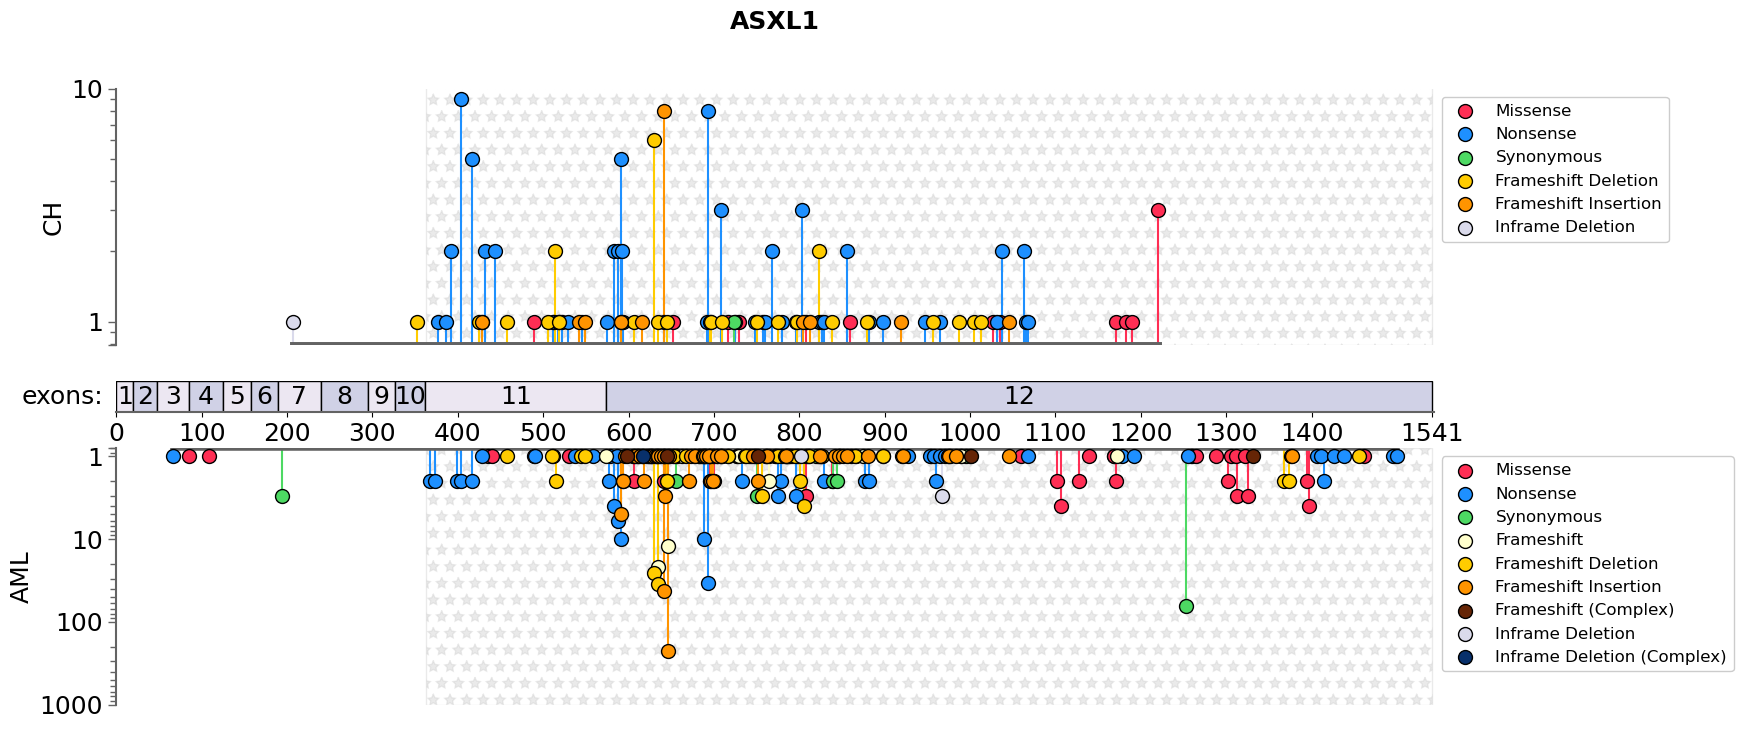

In [13]:
gene = 'ASXL1'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e1
AML_ymax = 1e3
CH_yticks = [10**-0.1, 10**0, 10**1]
CH_ytick_labels = ["0", "1", "10"]
AML_yticks = [10**-0.1, 10**0, 10**1, 10**2, 10**3]
AML_ytick_labels = ["0", "1", "10", "100", "1000"]
illumina_panel_position = [(574, 1541)]
twist_panel_position = [(363, 1541)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# BCOR

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


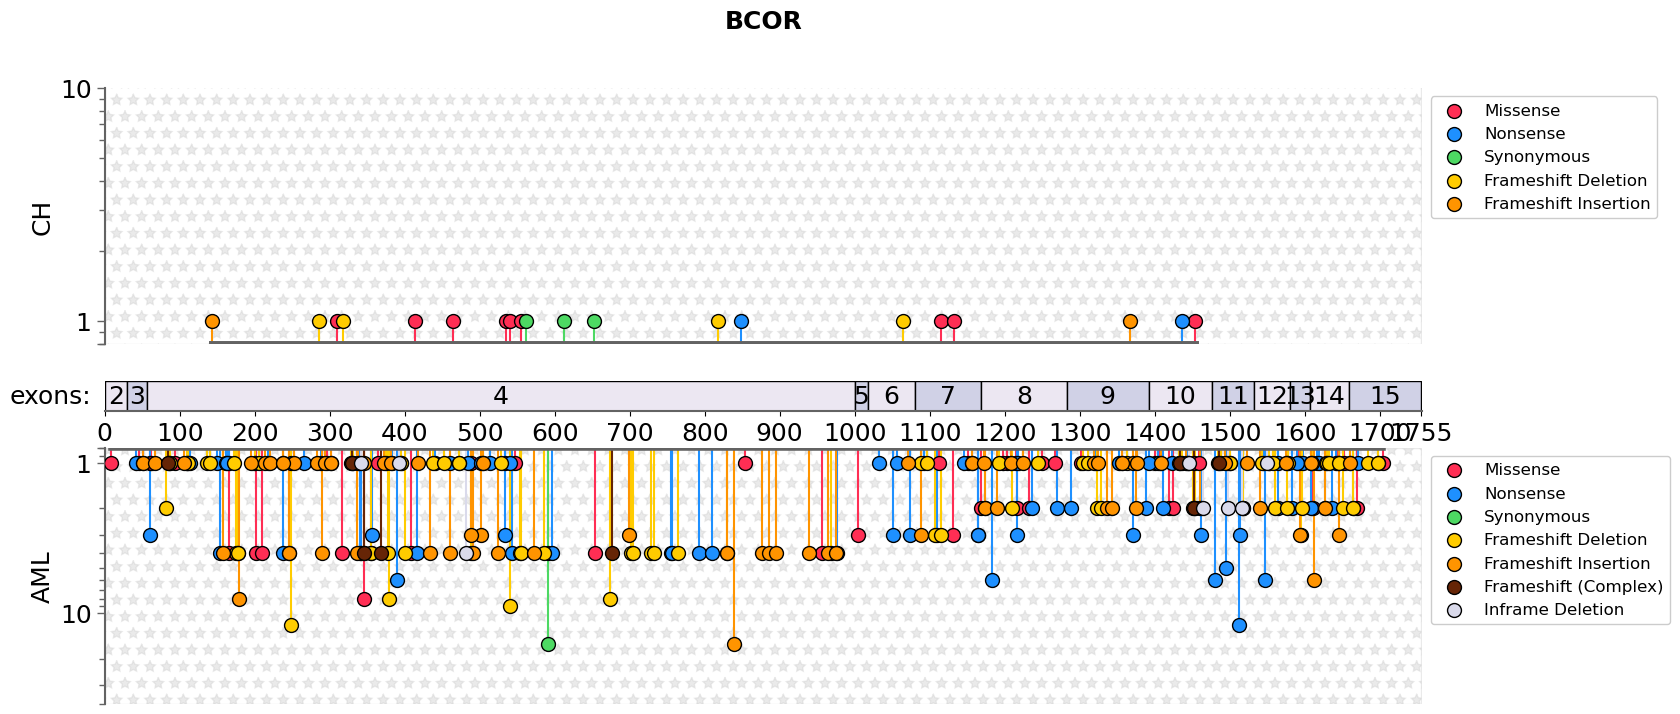

In [14]:
gene = 'BCOR'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e1
AML_ymax = 4e1
CH_yticks = [10**-0.1, 10**0, 10**1]
CH_ytick_labels = ["0", "1", "10"]
AML_yticks = [10**-0.1, 10**0, 10]
AML_ytick_labels = ["0", "1", "10"]
illumina_panel_position = [(0, 1755)]
twist_panel_position = [(0, 1755)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# BCORL1

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


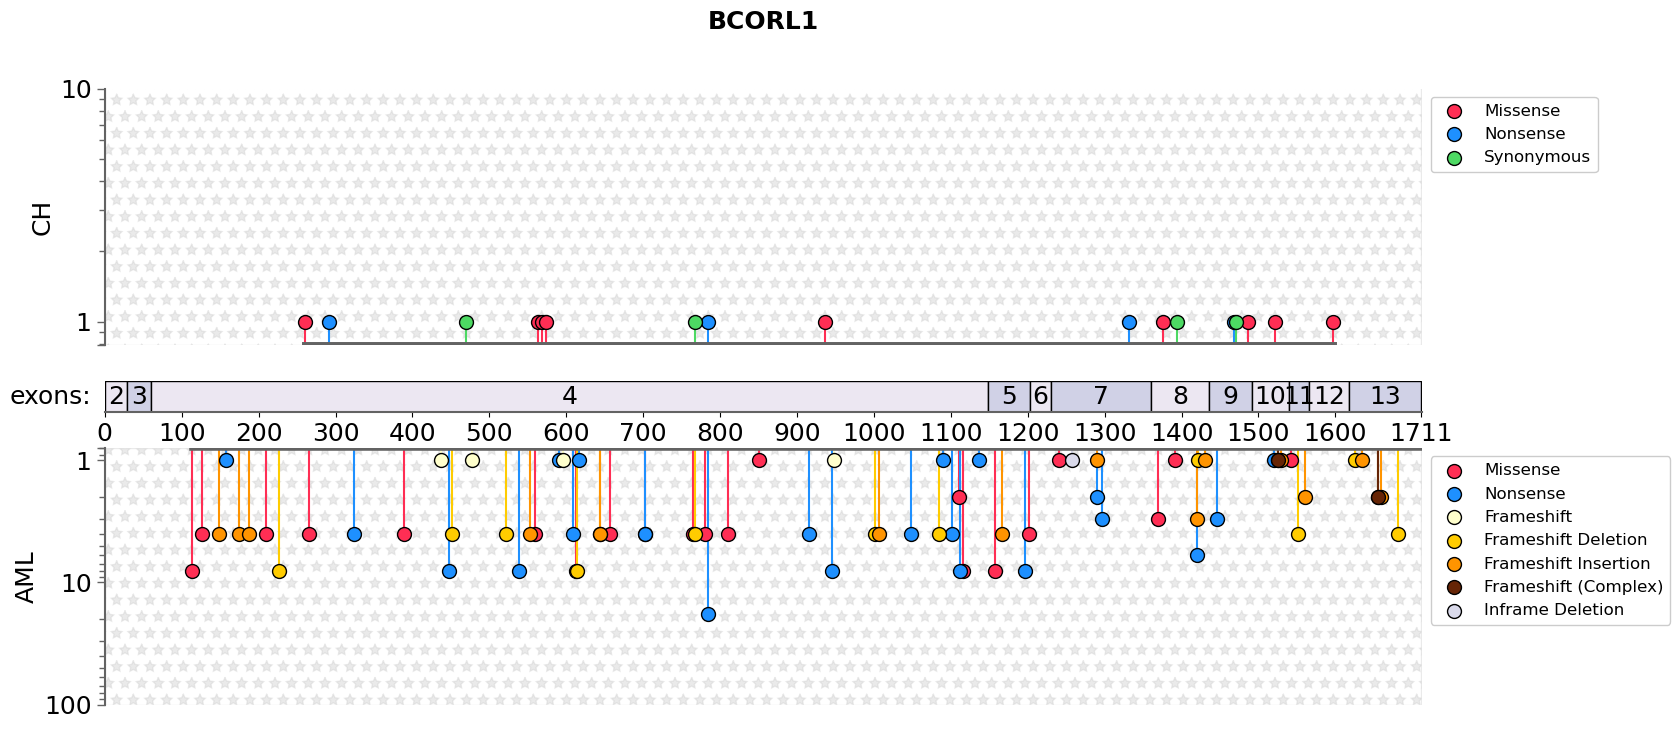

In [15]:
gene = 'BCORL1'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e1
AML_ymax = 1e2
CH_yticks = [10**-0.1, 10**0, 10**1]
CH_ytick_labels = ["0", "1", "10"]
AML_yticks = [10**-0.1, 10**0, 10, 100]
AML_ytick_labels = ["0", "1", "10", "100"]
illumina_panel_position = [(0, 1711)]
twist_panel_position = [(0, 1711)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# CBL

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


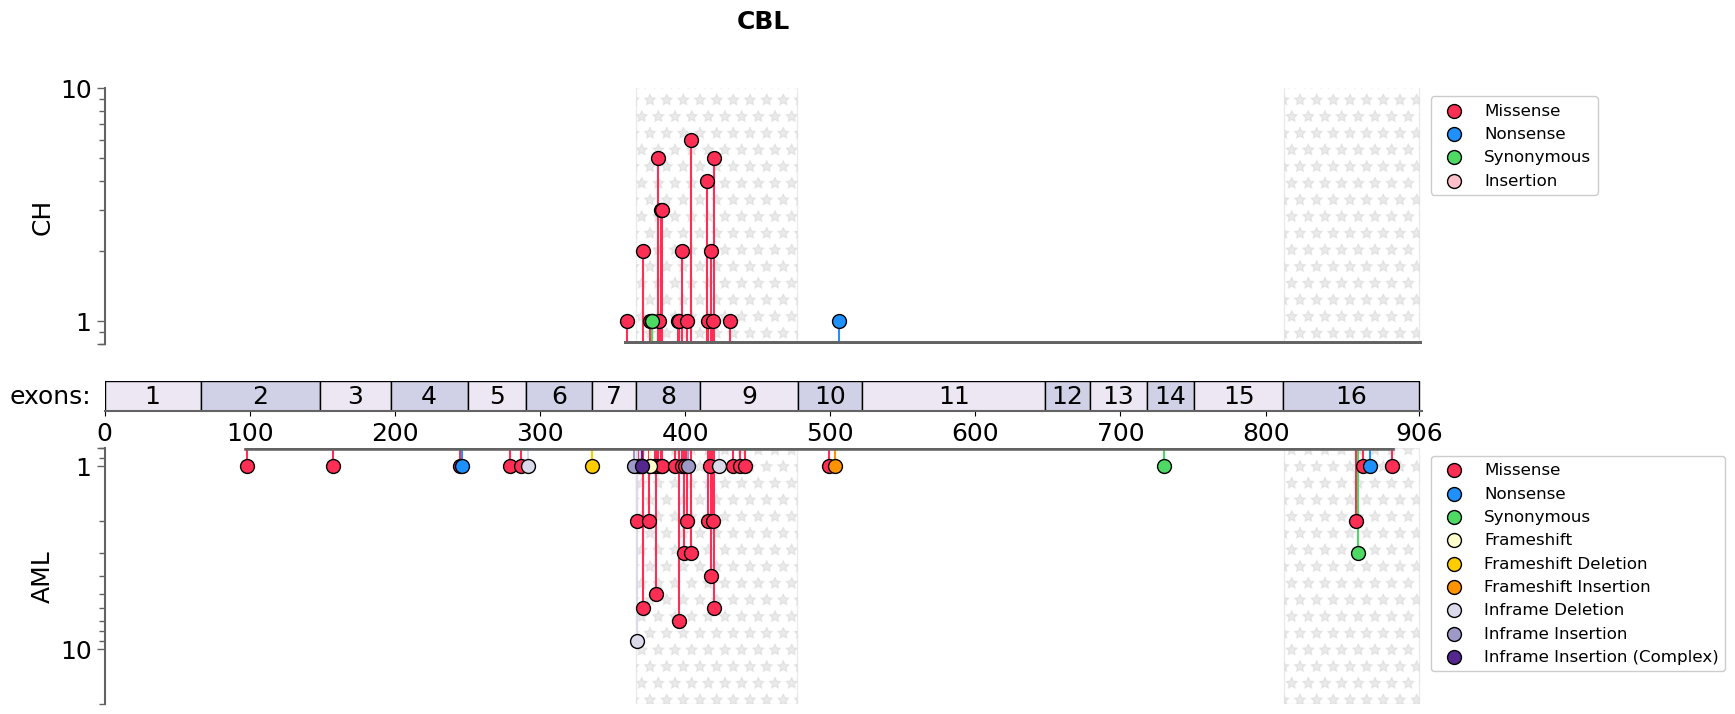

In [16]:
gene = 'CBL'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e1
AML_ymax = 2e1
CH_yticks = [10**-0.1, 10**0, 10**1]
CH_ytick_labels = ["0", "1", "10"]
AML_yticks = [10**-0.1, 10**0, 10**1]
AML_ytick_labels = ["0", "1", "10"]
illumina_panel_position = [(366, 477)]
twist_panel_position = [(366, 477), (813, 906)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# CEBPA

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


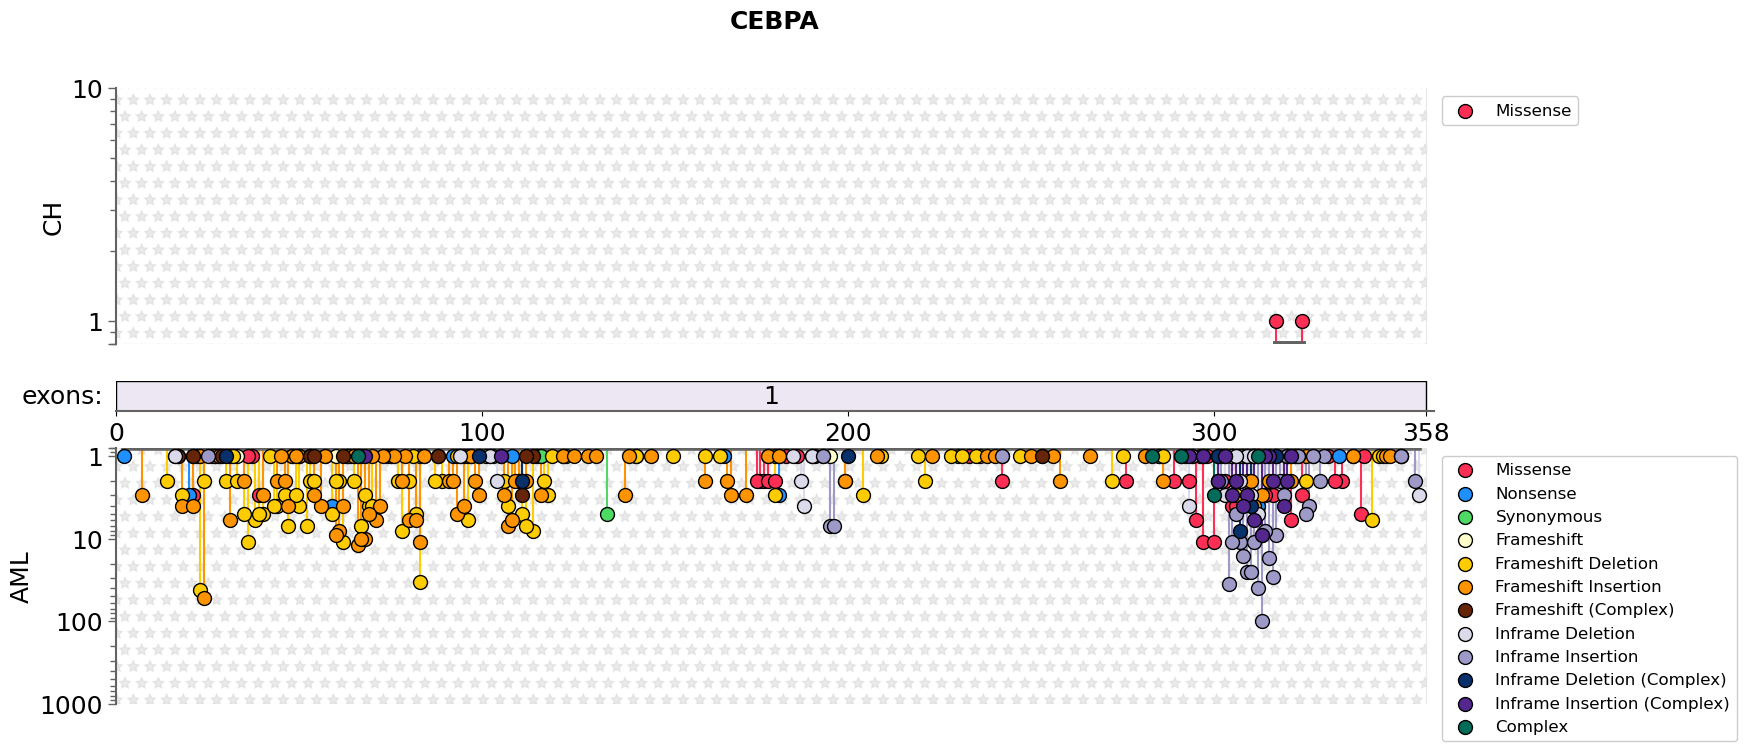

In [17]:
gene = 'CEBPA'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e1
AML_ymax = 1e3
CH_yticks = [10**-0.1, 10**0, 10**1]
CH_ytick_labels = ["0", "1", "10"]
AML_yticks = [10**-0.1, 10**0, 10, 100, 1000]
AML_ytick_labels = ["0", "1", "10", "100", "1000"]
illumina_panel_position = [(0, 358)]
twist_panel_position = [(0, 358)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# CHEK2

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


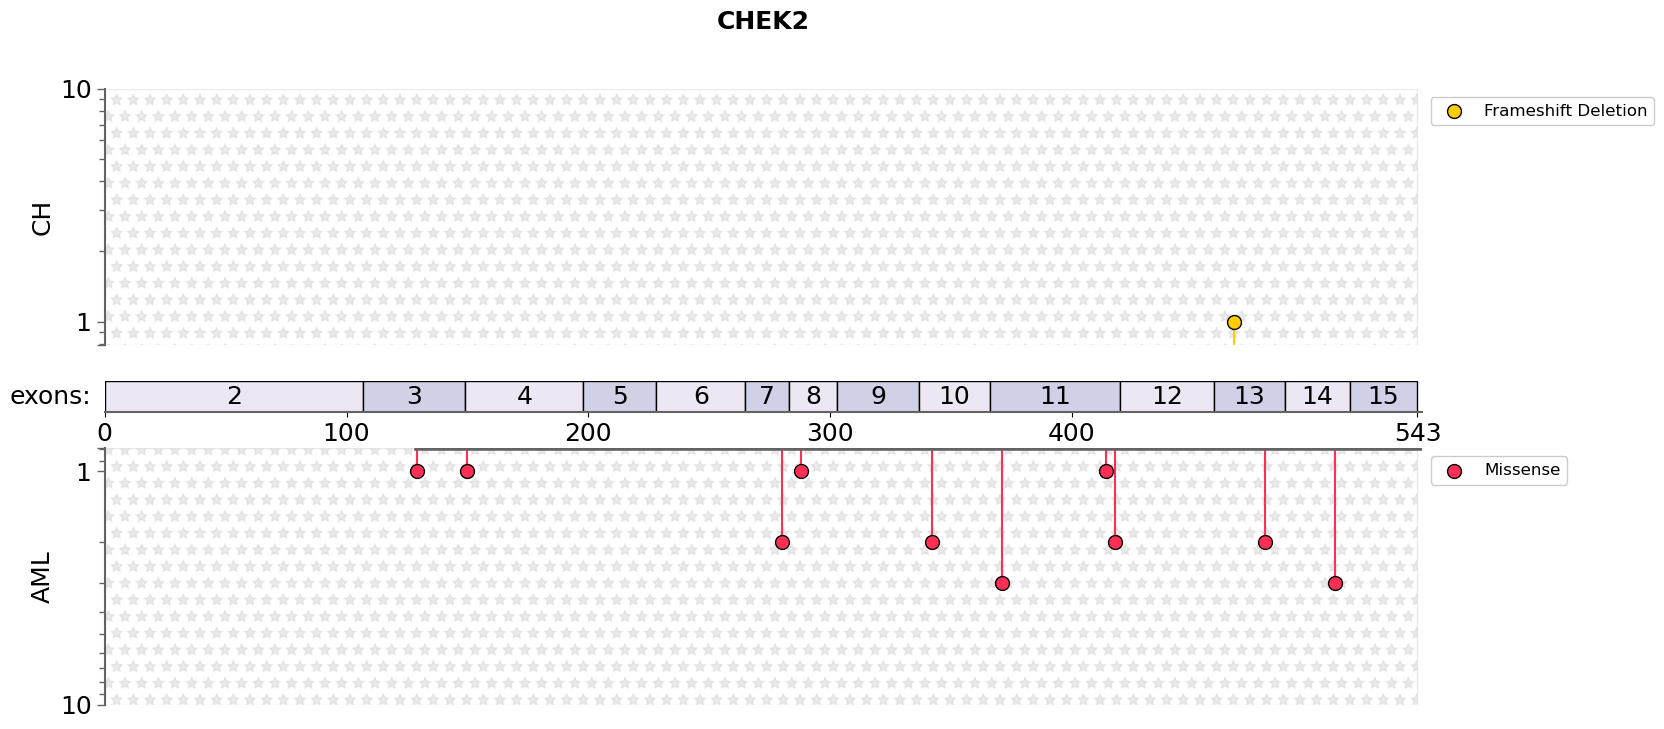

In [18]:
gene = 'CHEK2'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e1
AML_ymax = 1e1
CH_yticks = [10**-0.1, 10**0, 10**1]
CH_ytick_labels = ["0", "1", "10"]
AML_yticks = [10**-0.1, 10**0, 10]
AML_ytick_labels = ["0", "1", "10"]
illumina_panel_position = []
twist_panel_position = [(0, 543)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# CSF3R

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


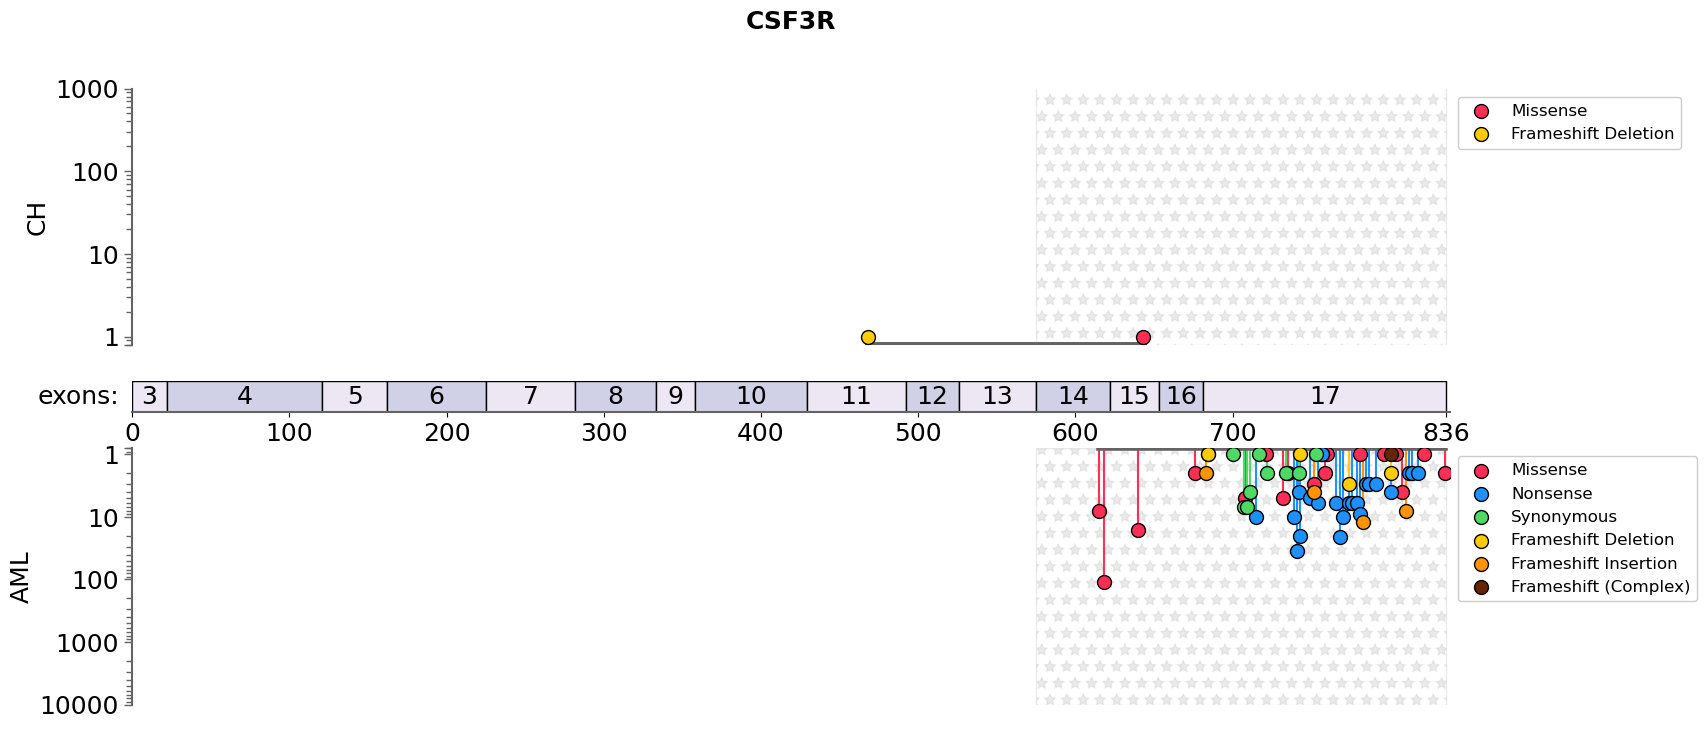

In [19]:
gene = 'CSF3R'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e3
AML_ymax = 1e4
CH_yticks = [10**-0.1, 10**0, 10**1, 10**2, 10**3]
CH_ytick_labels = ["0", "1", "10", "100", "1000"]
AML_yticks = [10**-0.1, 10**0, 10**1, 10**2, 10**3, 10**4]
AML_ytick_labels = ["0", "1", "10", "100", "1000", "10000"]
illumina_panel_position = [(575, 836)]
twist_panel_position = [(575, 836)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# DDX41

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


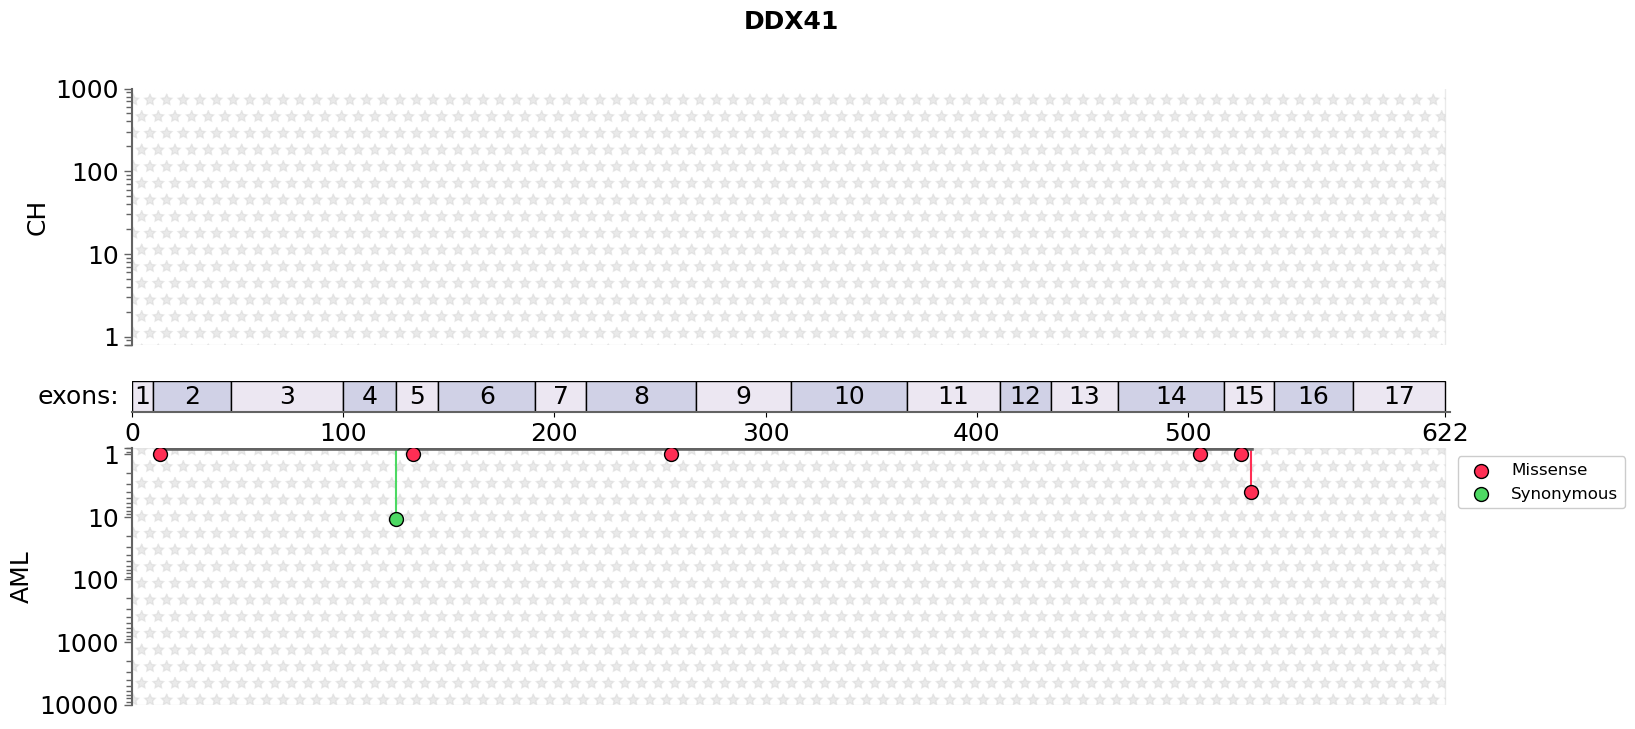

In [20]:
gene = 'DDX41'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e3
AML_ymax = 1e4
CH_yticks = [10**-0.1, 10**0, 10**1, 10**2, 10**3]
CH_ytick_labels = ["0", "1", "10", "100", "1000"]
AML_yticks = [10**-0.1, 10**0, 10**1, 10**2, 10**3, 10**4]
AML_ytick_labels = ["0", "1", "10", "100", "1000", "10000"]
illumina_panel_position = []
twist_panel_position = [(0, 622)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# DNMT3A

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


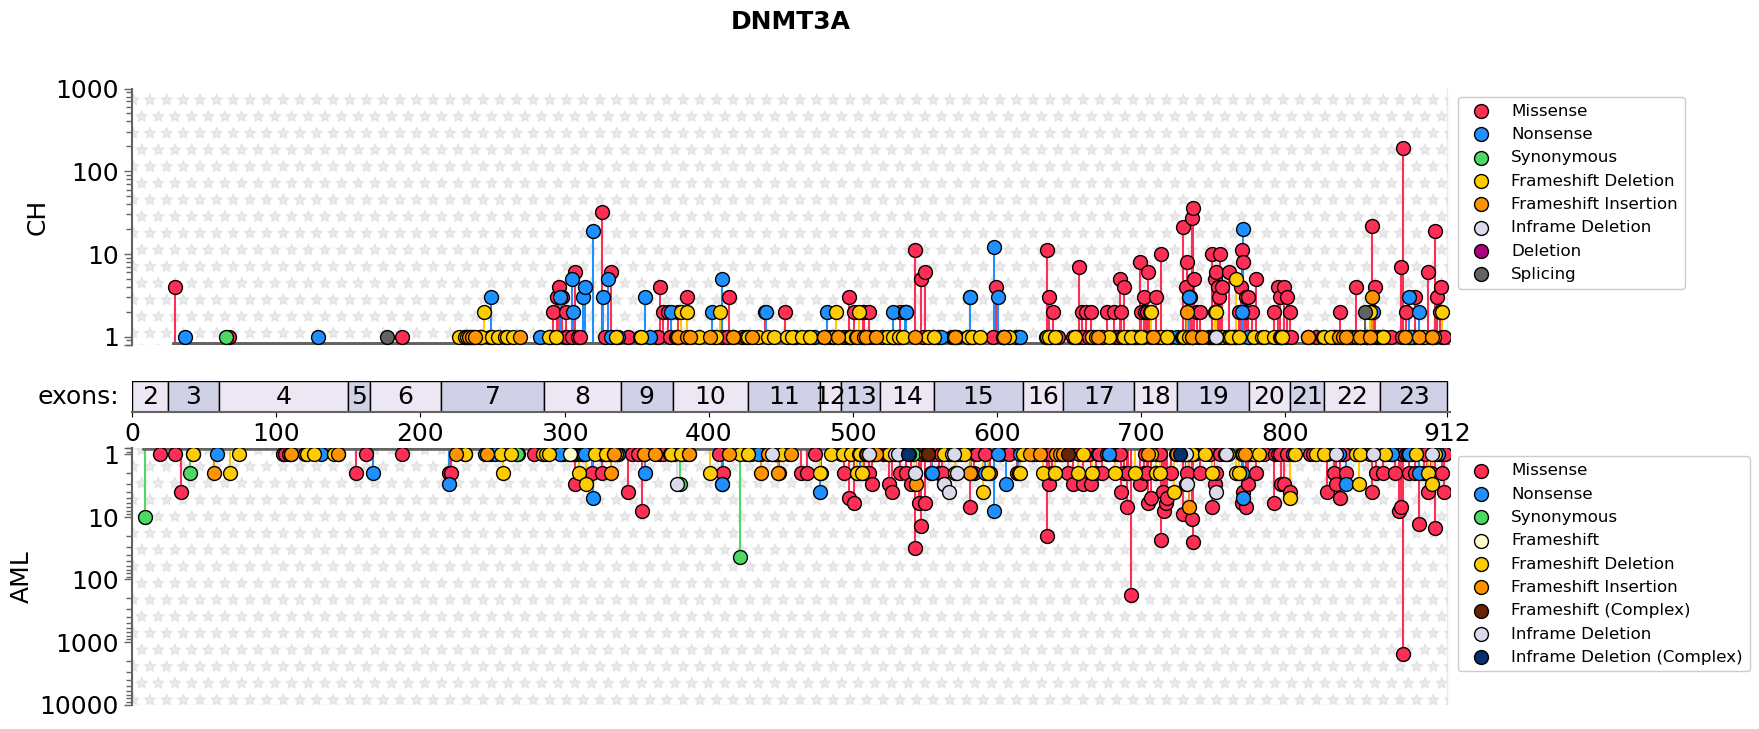

In [21]:
gene = 'DNMT3A'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e3
AML_ymax = 1e4
CH_yticks = [10**-0.1, 10**0, 10**1, 10**2, 10**3]
CH_ytick_labels = ["0", "1", "10", "100", "1000"]
AML_yticks = [10**-0.1, 10**0, 10**1, 10**2, 10**3, 10**4]
AML_ytick_labels = ["0", "1", "10", "100", "1000", "10000"]
illumina_panel_position = [(0, 912)]
twist_panel_position = [(0, 912)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# EZH2

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


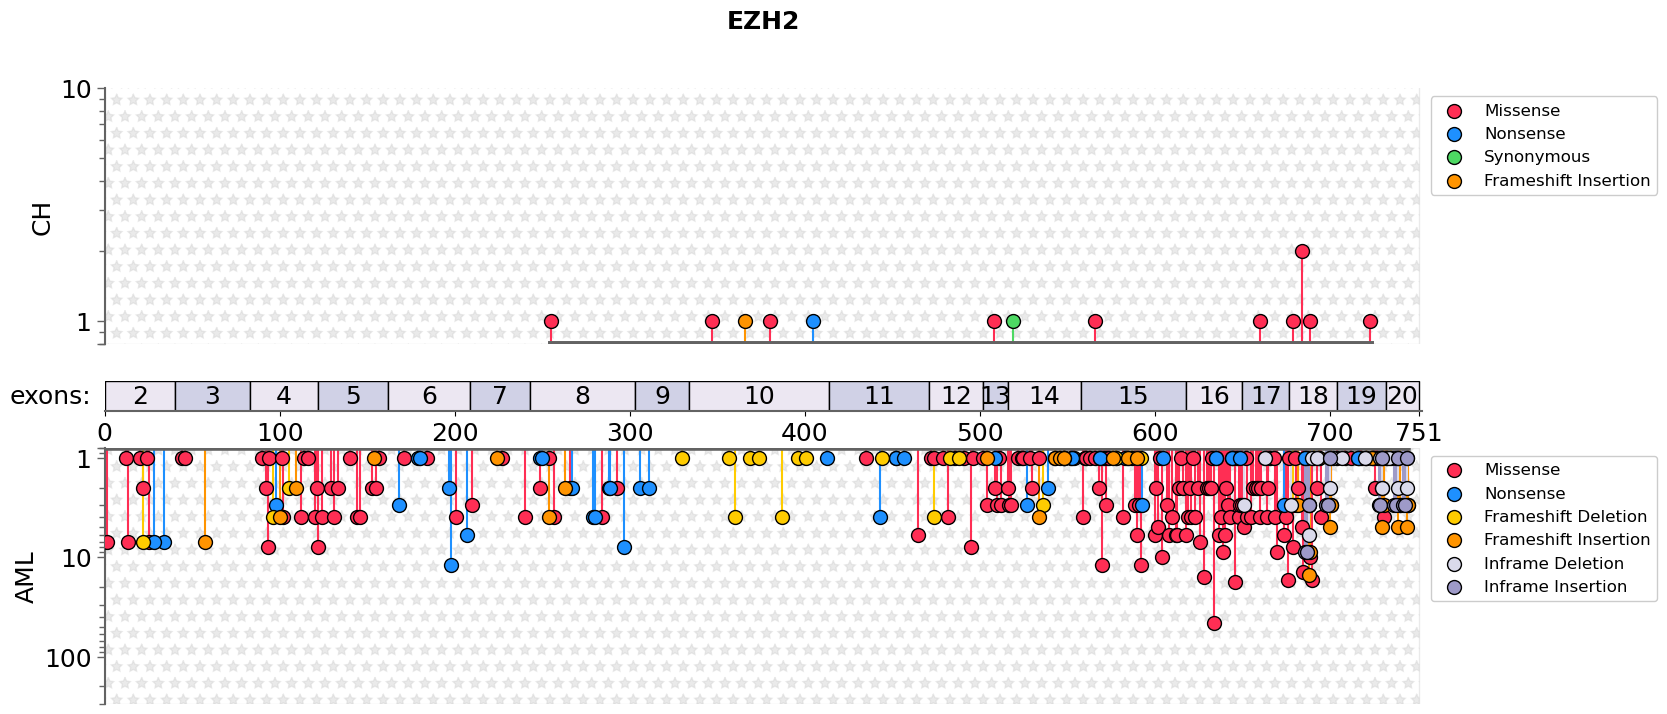

In [22]:
gene = 'EZH2'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e1
AML_ymax = 3e2
CH_yticks = [10**-0.1, 10**0, 10**1]
CH_ytick_labels = ["0", "1", "10"]
AML_yticks = [10**-0.1, 10**0, 10, 100]
AML_ytick_labels = ["0", "1", "10", "100"]
illumina_panel_position = [(0, 751)]
twist_panel_position = [(0, 751)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# FLT3

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


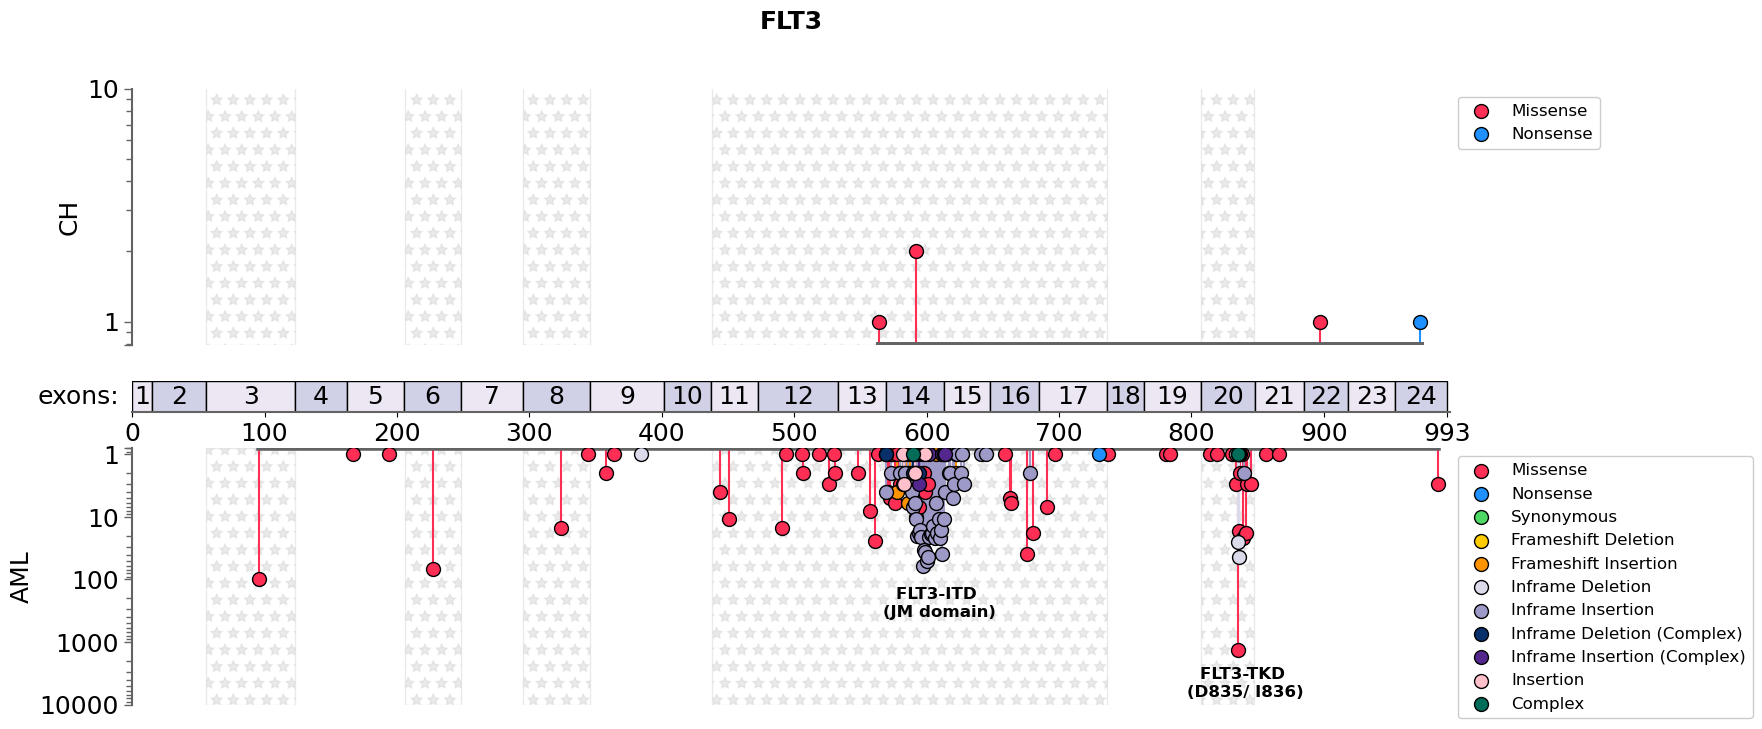

In [23]:
gene = 'FLT3'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e1
AML_ymax = 1e4
CH_yticks = [10**-0.1, 10**0, 10**1]
CH_ytick_labels = ["0", "1", "10"]
AML_yticks = [10**-0.1, 10**0, 10, 100, 1000, 10000]
AML_ytick_labels = ["0", "1", "10", "100", "1000", "10000"]
illumina_panel_position = [(569, 847), (807, 847)]
twist_panel_position = [(56, 123), (206, 248), (295, 346), (438, 736), (807, 847)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# GATA2

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


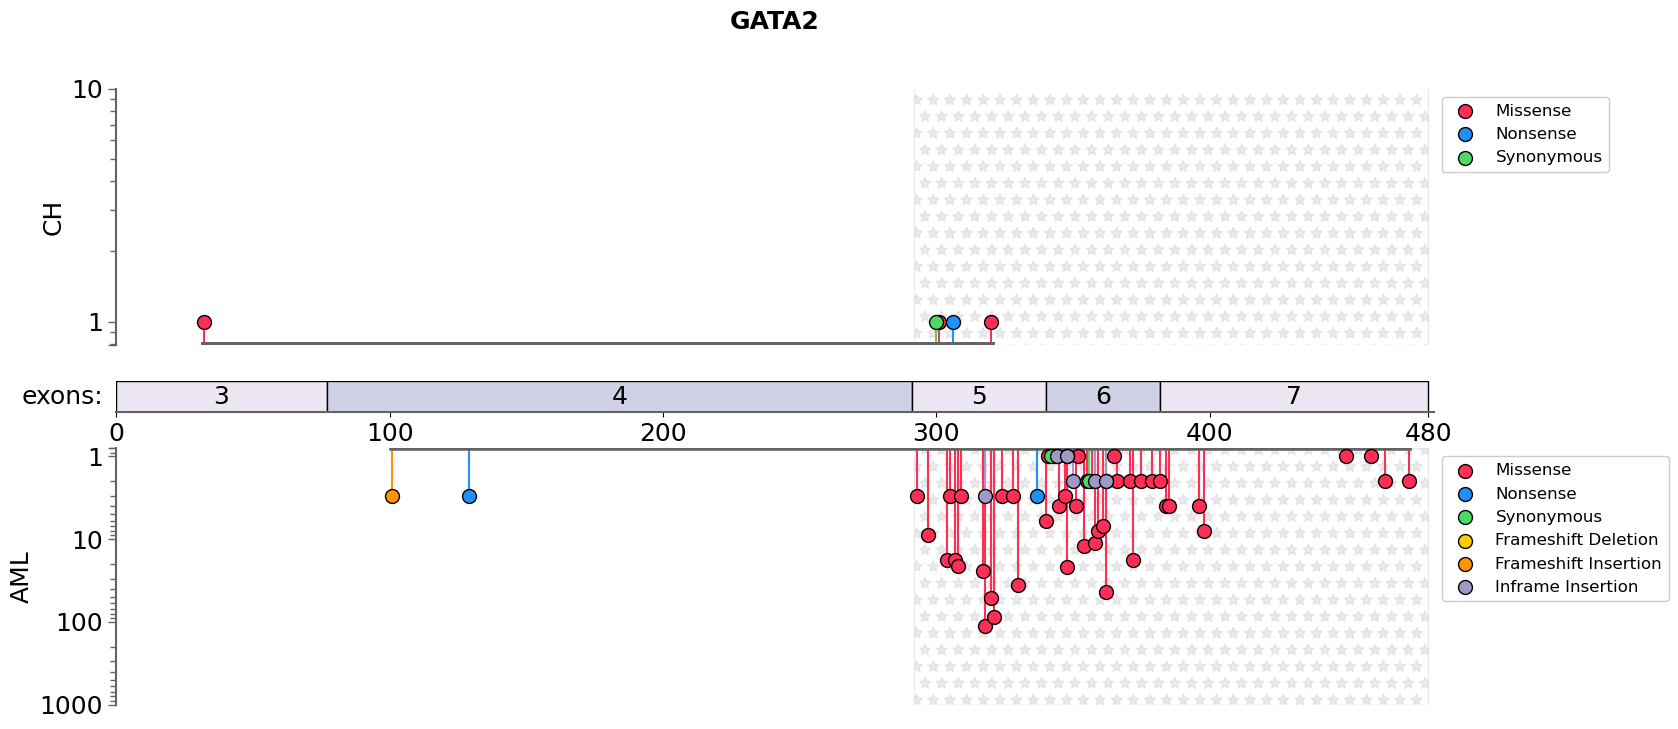

In [24]:
gene = 'GATA2'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e1
AML_ymax = 1e3
CH_yticks = [10**-0.1, 10**0, 10**1]
CH_ytick_labels = ["0", "1", "10"]
AML_yticks = [10**-0.1, 10**0, 10, 100, 1000]
AML_ytick_labels = ["0", "1", "10", "100", "1000"]
illumina_panel_position = [(0, 480)]
twist_panel_position = [(292, 480)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# GNAS

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


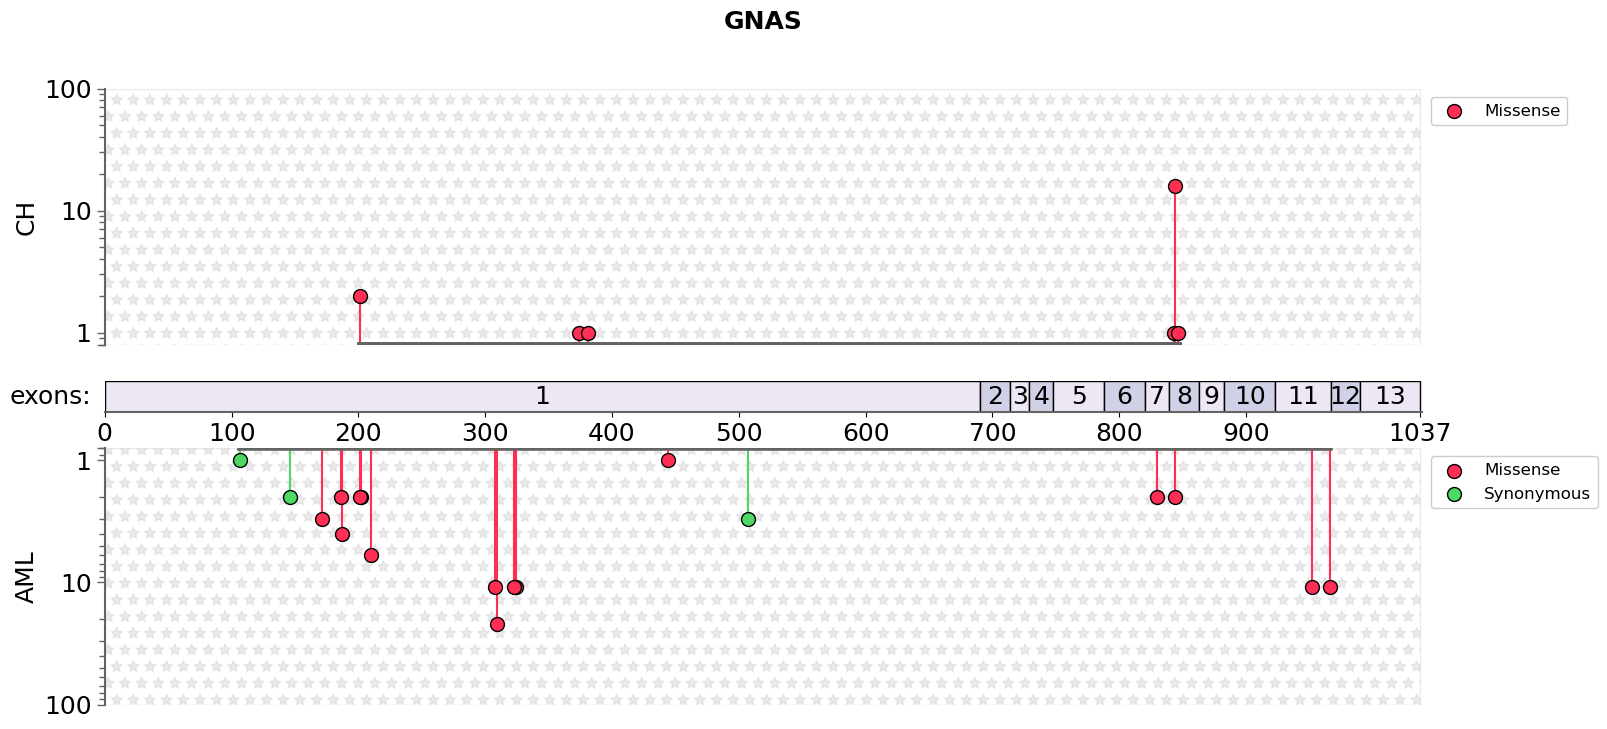

In [25]:
gene = 'GNAS'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e2
AML_ymax = 1e2
CH_yticks = [10**-0.1, 10**0, 10**1, 100]
CH_ytick_labels = ["0", "1", "10", "100"]
AML_yticks = [10**-0.1, 10**0, 10, 100]
AML_ytick_labels = ["0", "1", "10", "100"]
illumina_panel_position = [(839, 883)]
twist_panel_position = [(0, 1037)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

#  GNB1

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


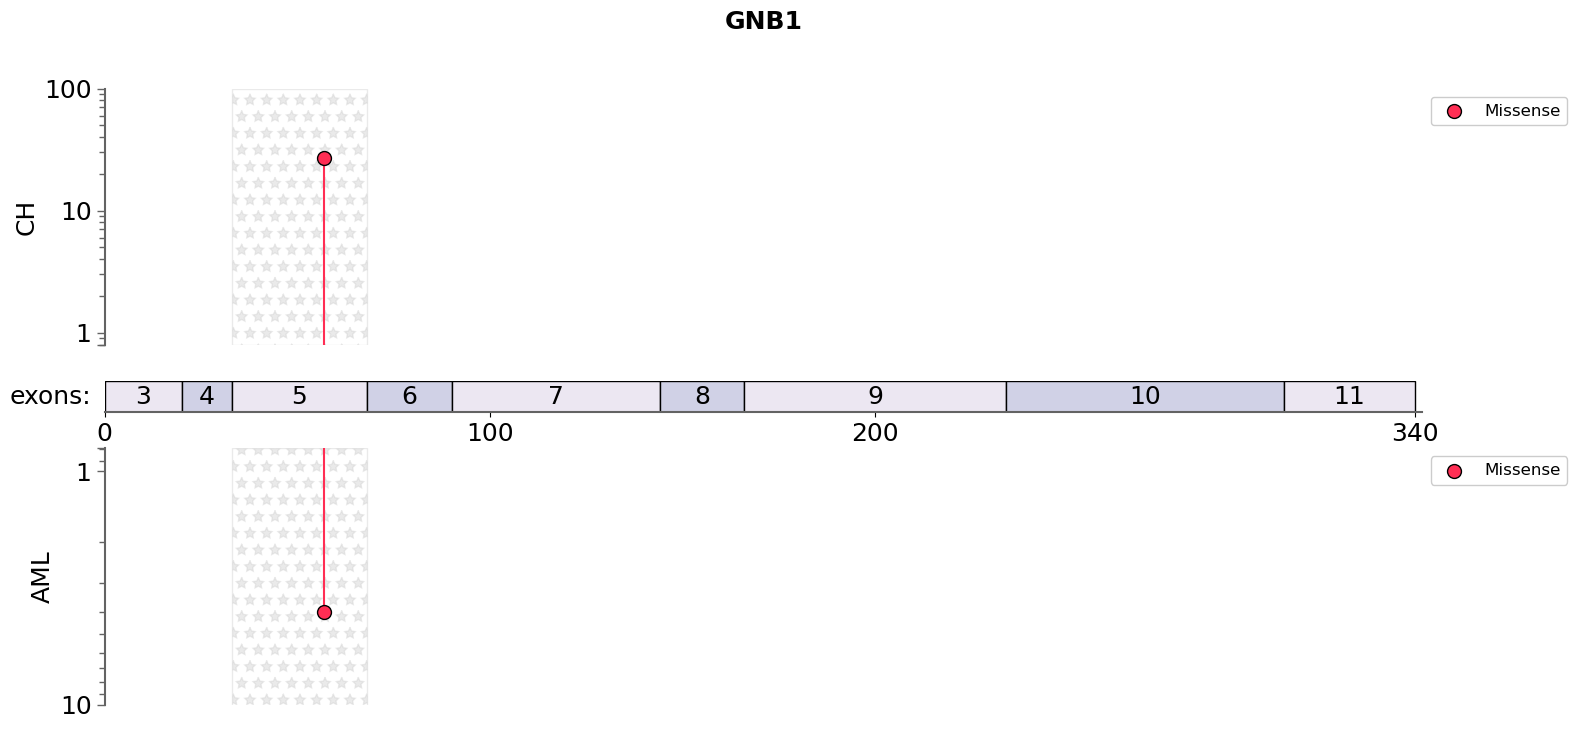

In [26]:
gene = 'GNB1'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e2
AML_ymax = 1e1
CH_yticks = [10**-0.1, 10**0, 10**1, 1e2]
CH_ytick_labels = ["0", "1", "10", "100"]
AML_yticks = [10**-0.1, 10**0, 10]
AML_ytick_labels = ["0", "1", "10"]
illumina_panel_position = []
twist_panel_position = [(33, 68)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# IDH1

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


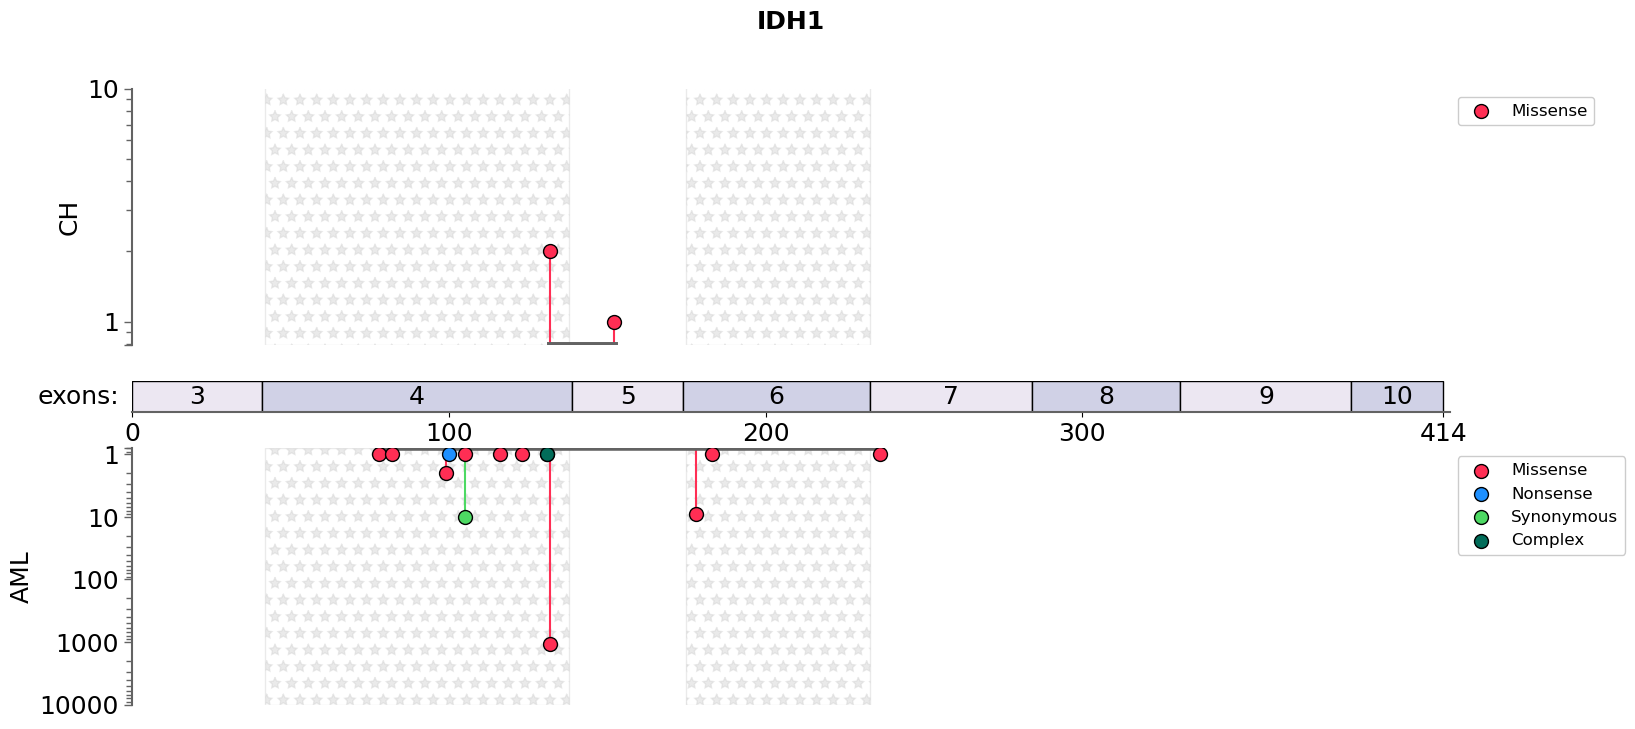

In [27]:
gene = 'IDH1'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e1
AML_ymax = 1e4
CH_yticks = [10**-0.1, 10**0, 10**1]
CH_ytick_labels = ["0", "1", "10"]
AML_yticks = [10**-0.1, 10**0, 10, 100, 1000, 10000]
AML_ytick_labels = ["0", "1", "10", "100", "1000", "10000"]
illumina_panel_position = [(42, 138)]
twist_panel_position = [(42, 138), (175, 233)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# IDH2

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


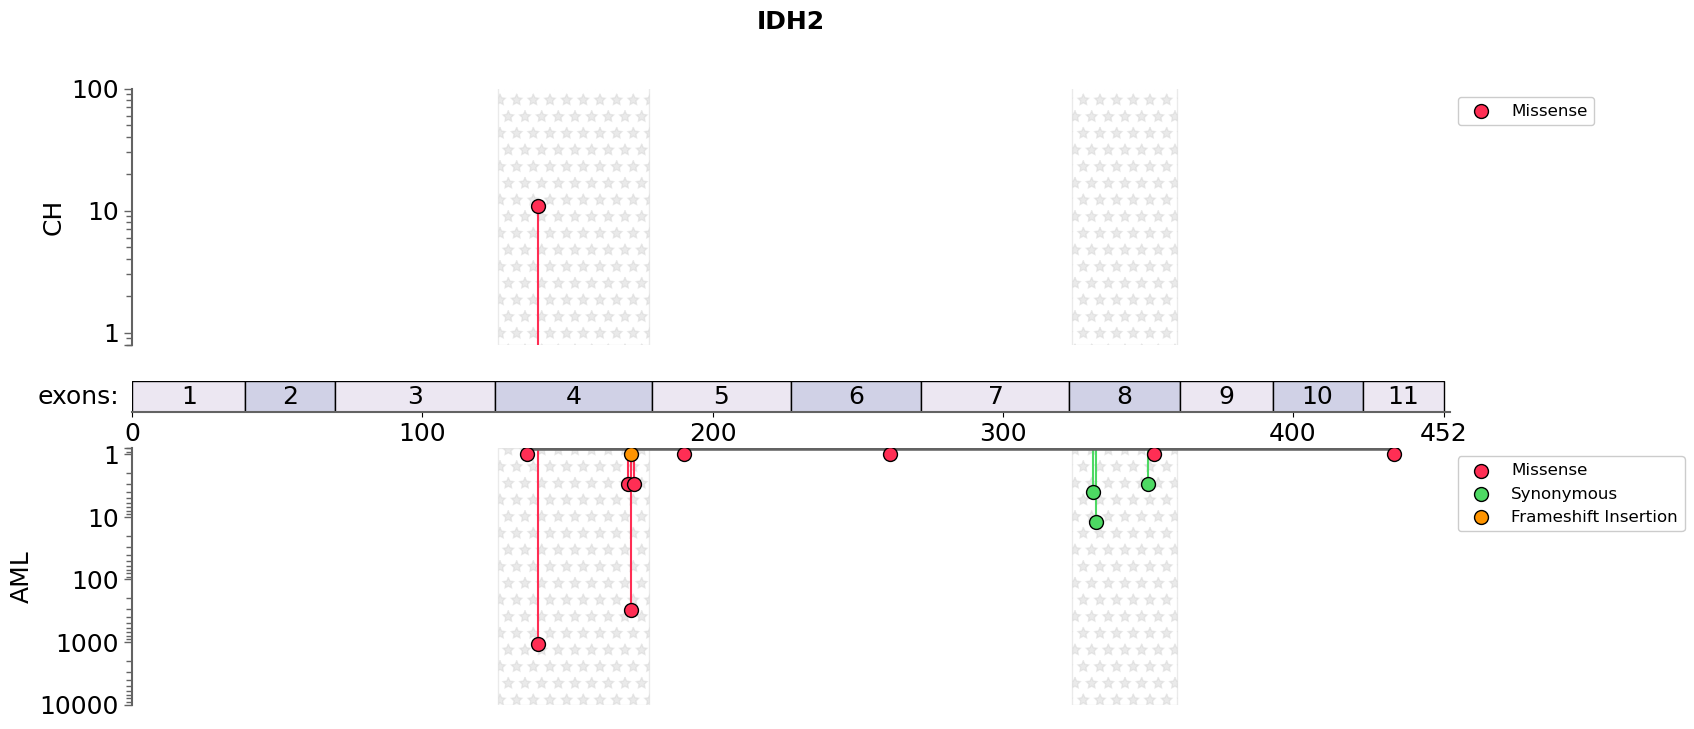

In [28]:
gene = 'IDH2'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e1
AML_ymax = 1e4
CH_yticks = [10**-0.1, 10**0, 10**1, 100]
CH_ytick_labels = ["0", "1", "10", "100"]
AML_yticks = [10**-0.1, 10**0, 10, 100, 1000, 10000]
AML_ytick_labels = ["0", "1", "10", "100", "1000", "10000"]
illumina_panel_position = [(126, 178)]
twist_panel_position = [(126, 178), (324, 360)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# JAK2

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


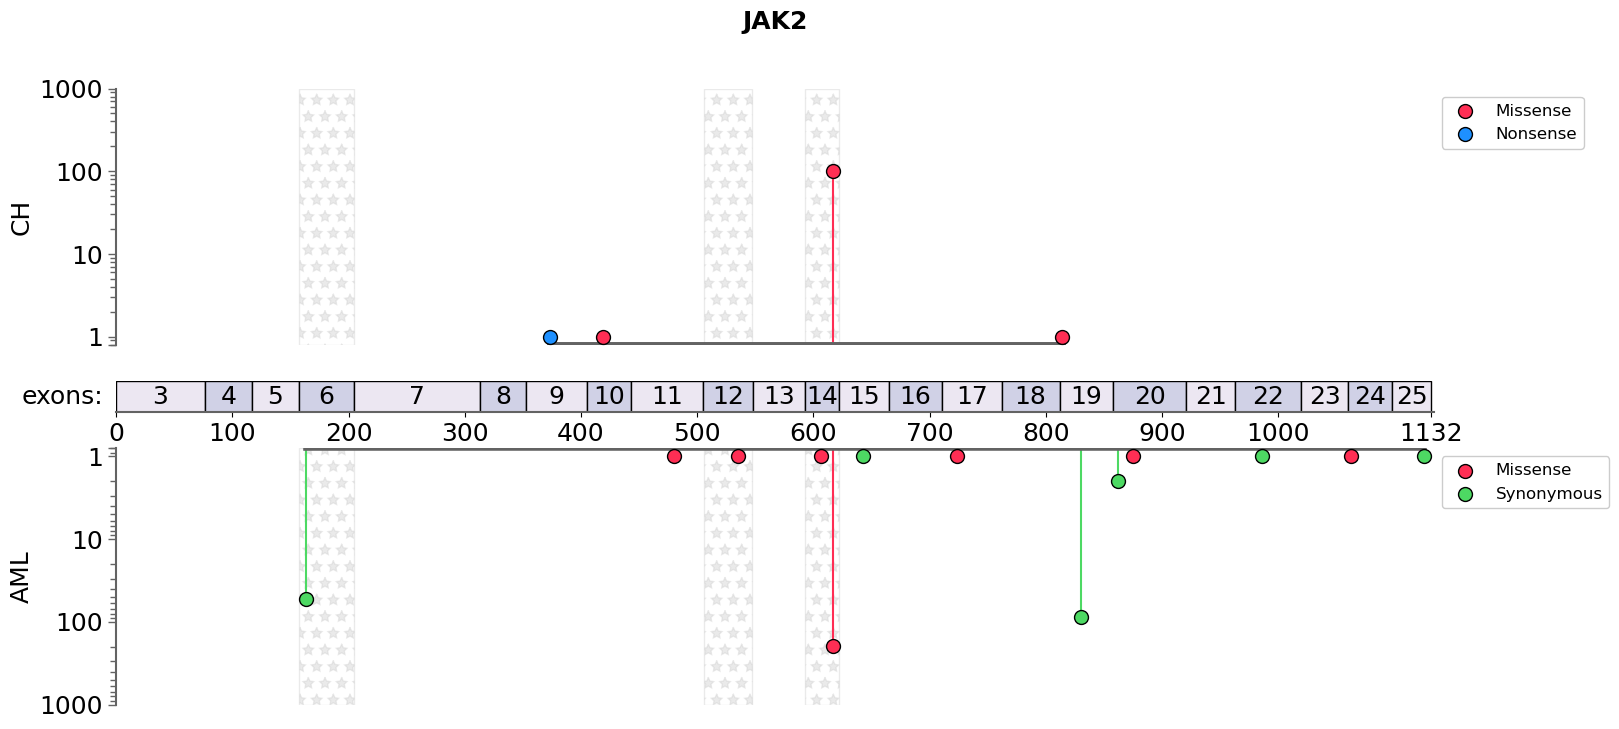

In [29]:
gene = 'JAK2'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e3
AML_ymax = 1e3
CH_yticks = [10**-0.1, 10**0, 10**1, 1e2, 1e3]
CH_ytick_labels = ["0", "1", "10", "100", "1000"]
AML_yticks = [10**-0.1, 10**0, 10**1, 10**2, 1e3]
AML_ytick_labels = ["0", "1", "10", "100", "1000"]
illumina_panel_position = [(506, 547), (593, 622)]
twist_panel_position = [(157, 205), (506, 547), (593, 622)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# KIT

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


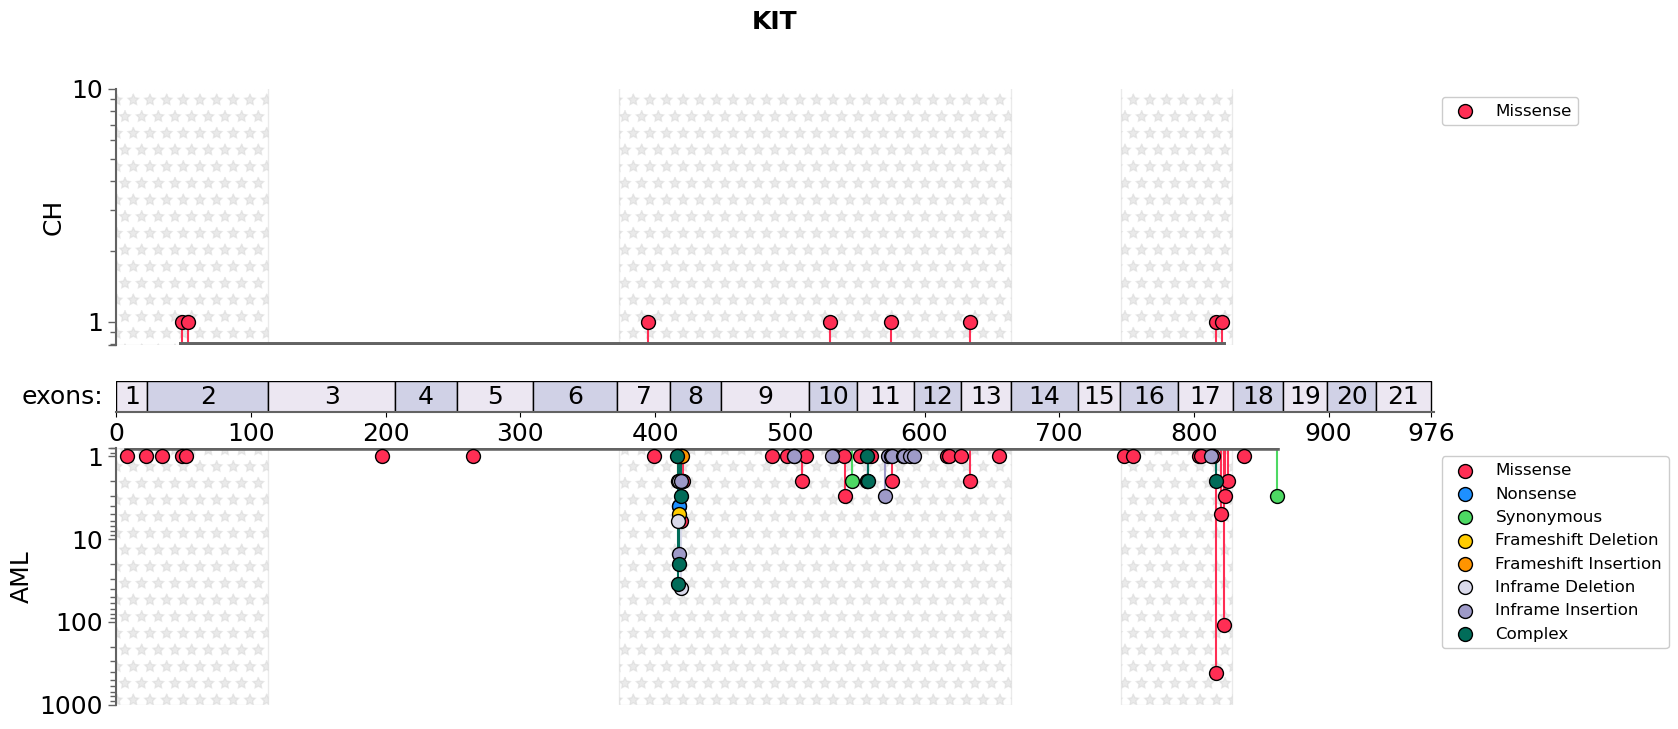

In [30]:
gene = 'KIT'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e1
AML_ymax = 1e3
CH_yticks = [10**-0.1, 10**0, 10**1]
CH_ytick_labels = ["0", "1", "10"]
AML_yticks = [10**-0.1, 10**0, 10, 100, 1000]
AML_ytick_labels = ["0", "1", "10", "100", "1000"]
illumina_panel_position = [(24, 113), (412, 592), (628, 664), (788, 828)]
twist_panel_position = [(0, 113), (373, 664), (746, 828)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# KRAS

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


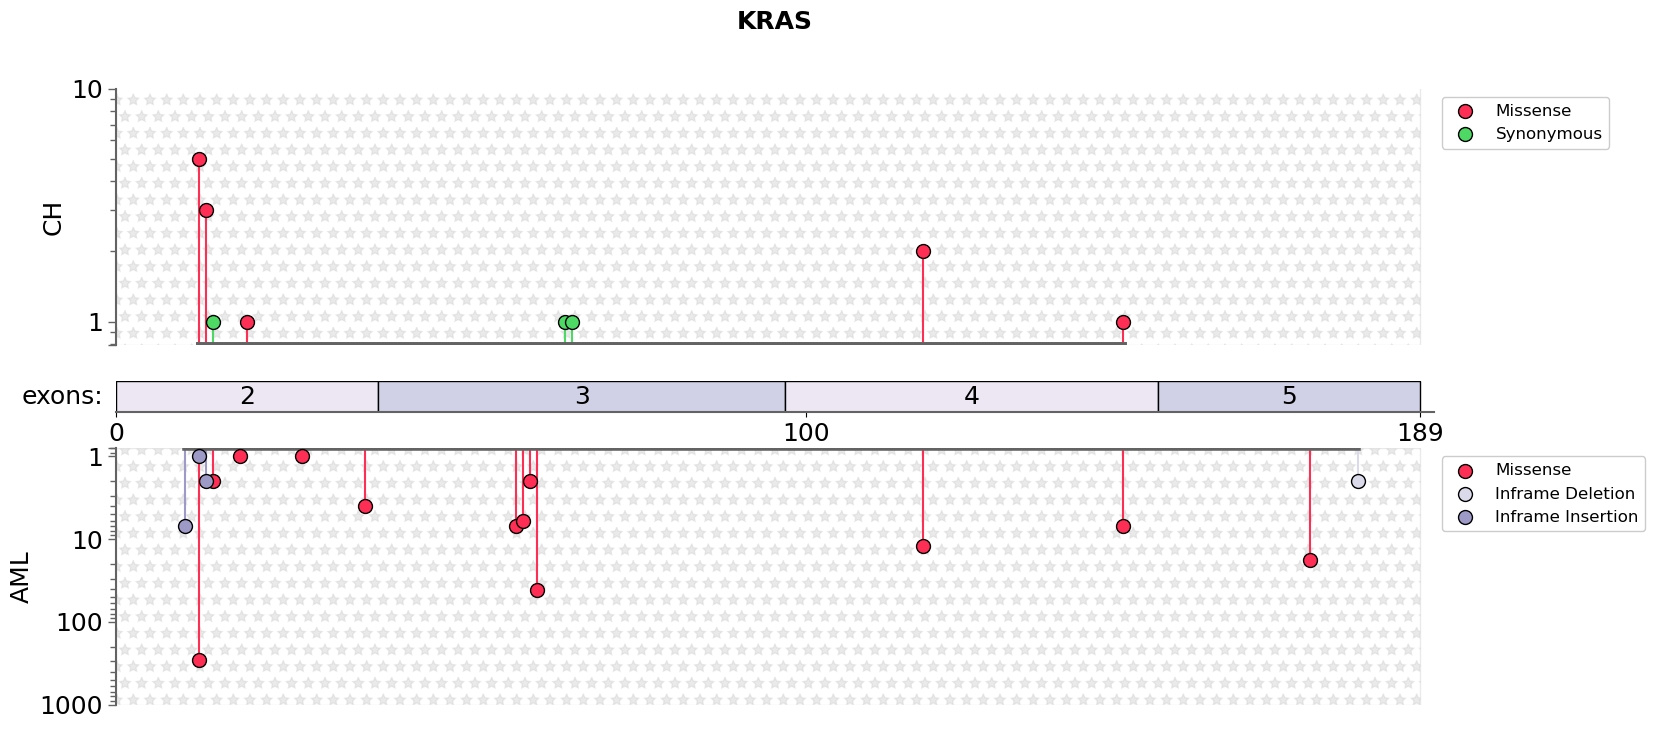

In [31]:
gene = 'KRAS'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e1
AML_ymax = 1e3
CH_yticks = [10**-0.1, 10**0, 10**1]
CH_ytick_labels = ["0", "1", "10"]
AML_yticks = [10**-0.1, 10**0, 10**1, 10**2, 1e3]
AML_ytick_labels = ["0", "1", "10", "100", "1000"]
illumina_panel_position = [(0, 97)]
twist_panel_position = [(0, 189)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# MPL

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


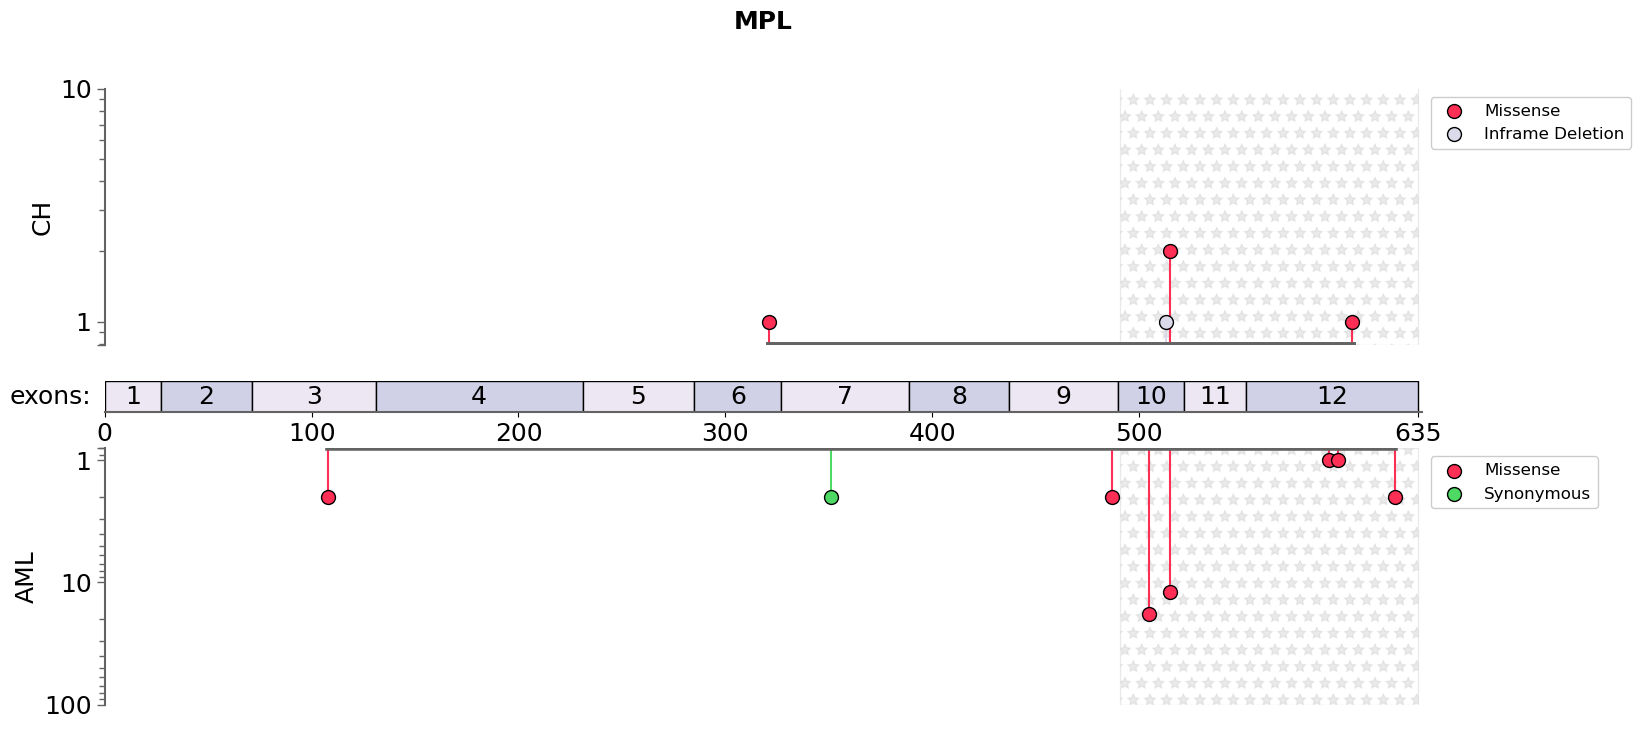

In [32]:
gene = 'MPL'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e1
AML_ymax = 1e2
CH_yticks = [10**-0.1, 10**0, 10**1]
CH_ytick_labels = ["0", "1", "10"]
AML_yticks = [10**-0.1, 10**0, 10, 100]
AML_ytick_labels = ["0", "1", "10", "100"]
illumina_panel_position = [(491, 522)]
twist_panel_position = [(491, 635)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# NPM1

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


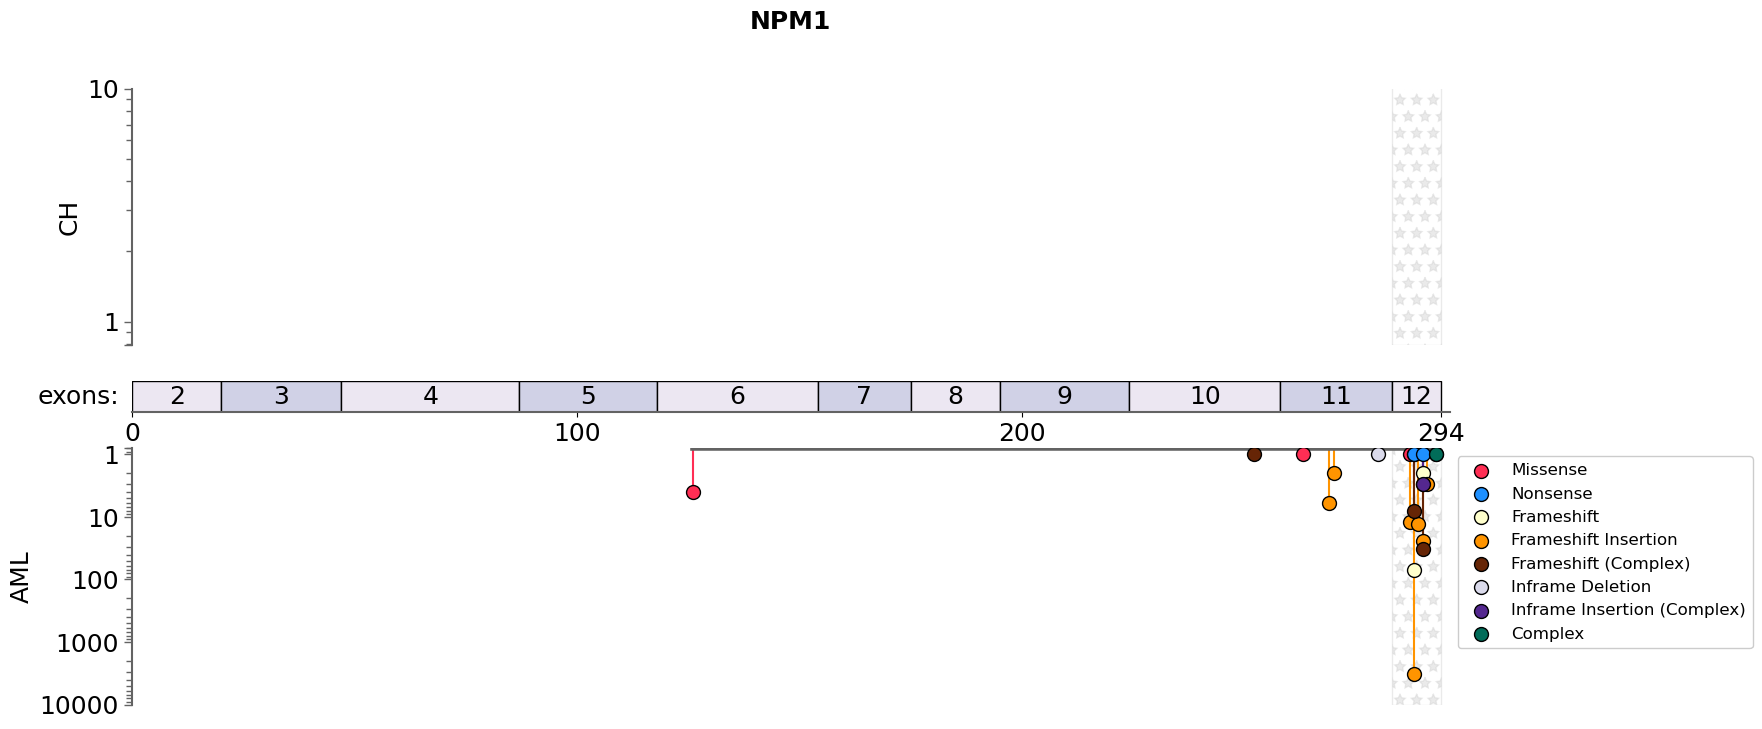

In [33]:
gene = 'NPM1'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e1
AML_ymax = 1e4
CH_yticks = [10**-0.1, 10**0, 10**1]
CH_ytick_labels = ["0", "1", "10"]
AML_yticks = [10**-0.1, 10**0, 10, 100, 1000, 10000]
AML_ytick_labels = ["0", "1", "10", "100", "1000", "10000"]
illumina_panel_position = [(283, 294)]
twist_panel_position = [(283, 294)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# NRAS

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


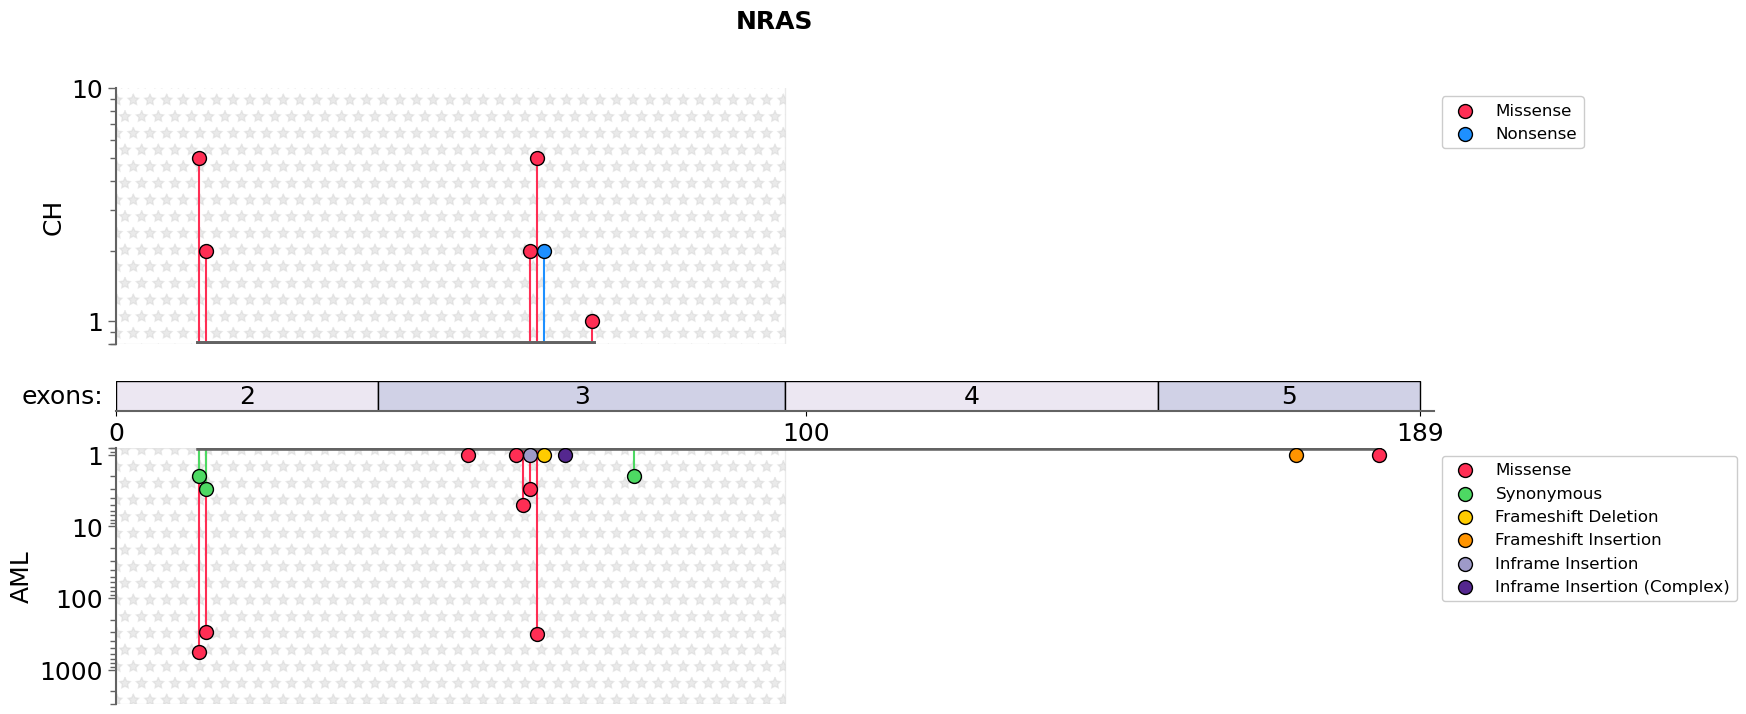

In [34]:
gene = 'NRAS'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e1
AML_ymax = 3e3
CH_yticks = [10**-0.1, 10**0, 10**1]
CH_ytick_labels = ["0", "1", "10"]
AML_yticks = [10**-0.1, 10**0, 10, 100, 1000]
AML_ytick_labels = ["0", "1", "10", "100", "1000"]
illumina_panel_position = [(0, 97)]
twist_panel_position = [(0, 97)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# PPM1D

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


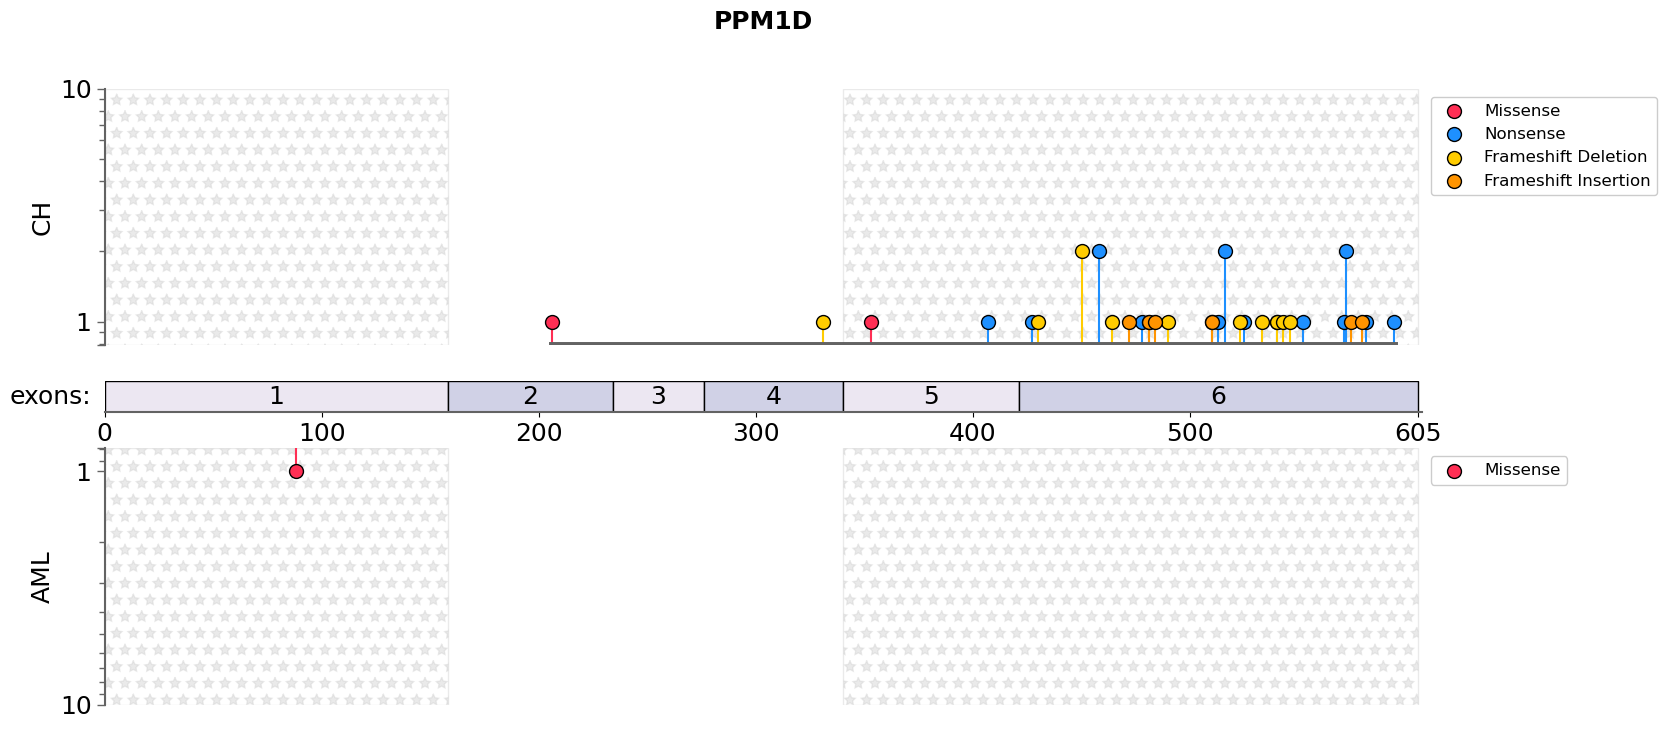

In [35]:
gene = 'PPM1D'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e1
AML_ymax = 1e1
CH_yticks = [10**-0.1, 10**0, 10**1]
CH_ytick_labels = ["0", "1", "10"]
AML_yticks = [10**-0.1, 10**0, 10]
AML_ytick_labels = ["0", "1", "10"]
illumina_panel_position = []
twist_panel_position = [(0, 158), (340, 605)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# PTPN11

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


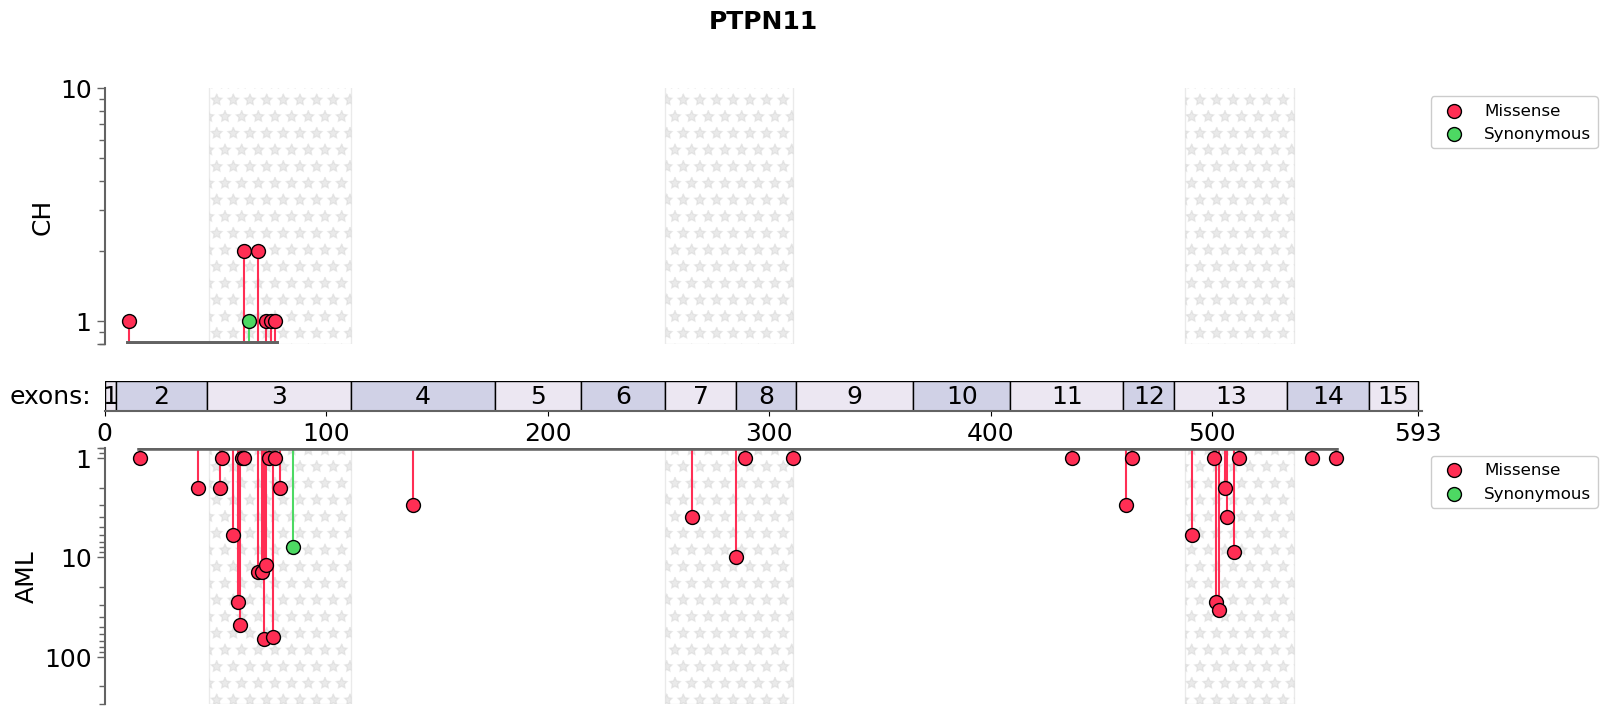

In [36]:
gene = 'PTPN11'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e1
AML_ymax = 3e2
CH_yticks = [10**-0.1, 10**0, 10**1]
CH_ytick_labels = ["0", "1", "10"]
AML_yticks = [10**-0.1, 10**0, 10, 100]
AML_ytick_labels = ["0", "1", "10", "100"]
illumina_panel_position = [(47, 111), (488, 537)]
twist_panel_position = [(47, 111), (253, 311), (488, 537)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# RAD21

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


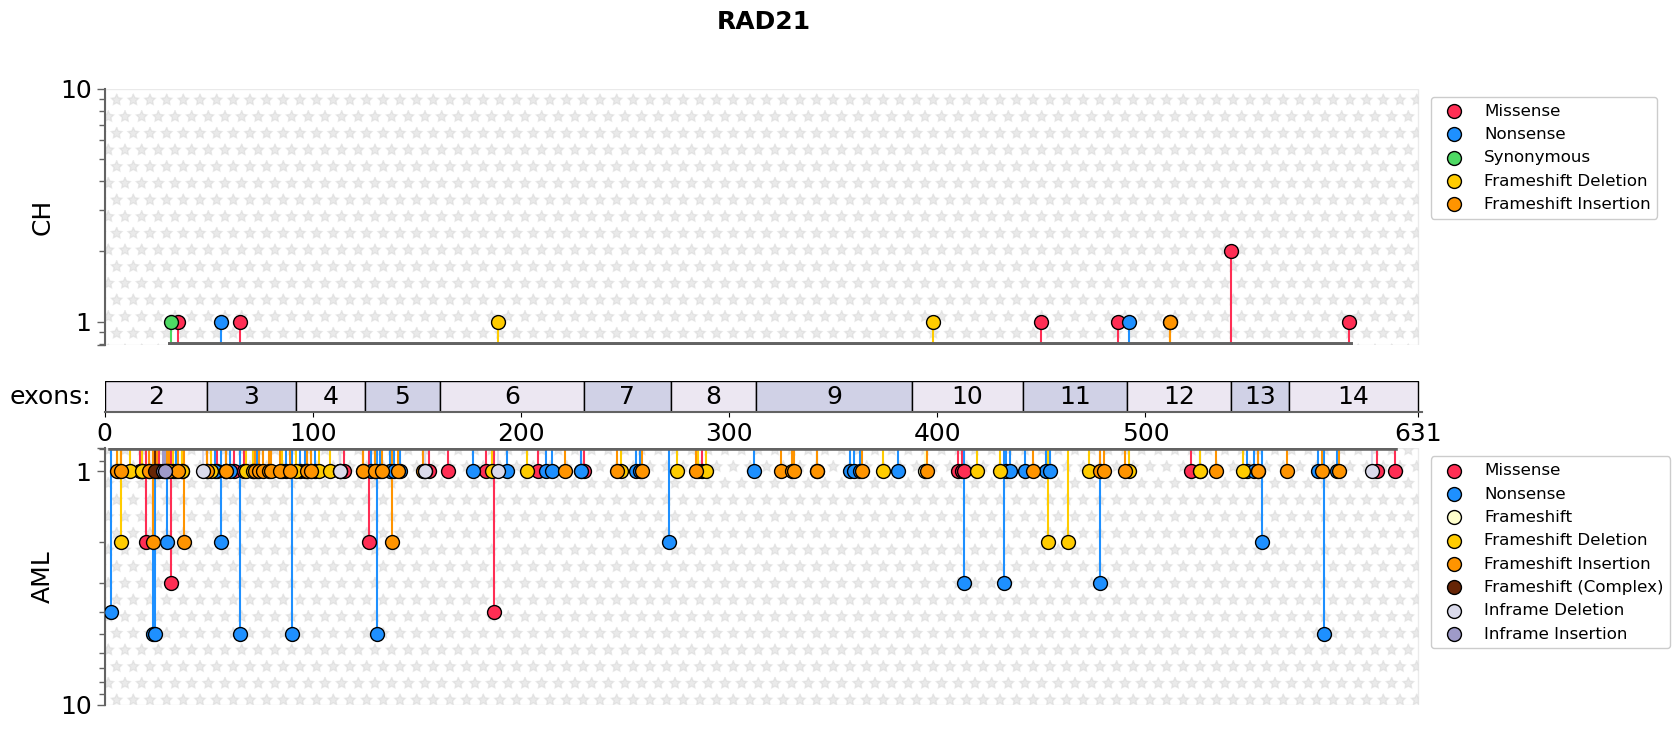

In [37]:
gene = 'RAD21'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e1
AML_ymax = 1e1
CH_yticks = [10**-0.1, 10**0, 10**1]
CH_ytick_labels = ["0", "1", "10"]
AML_yticks = [10**-0.1, 10**0, 10]
AML_ytick_labels = ["0", "1", "10"]
illumina_panel_position = [(0, 631)]
twist_panel_position = [(0, 631)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# RUNX1

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


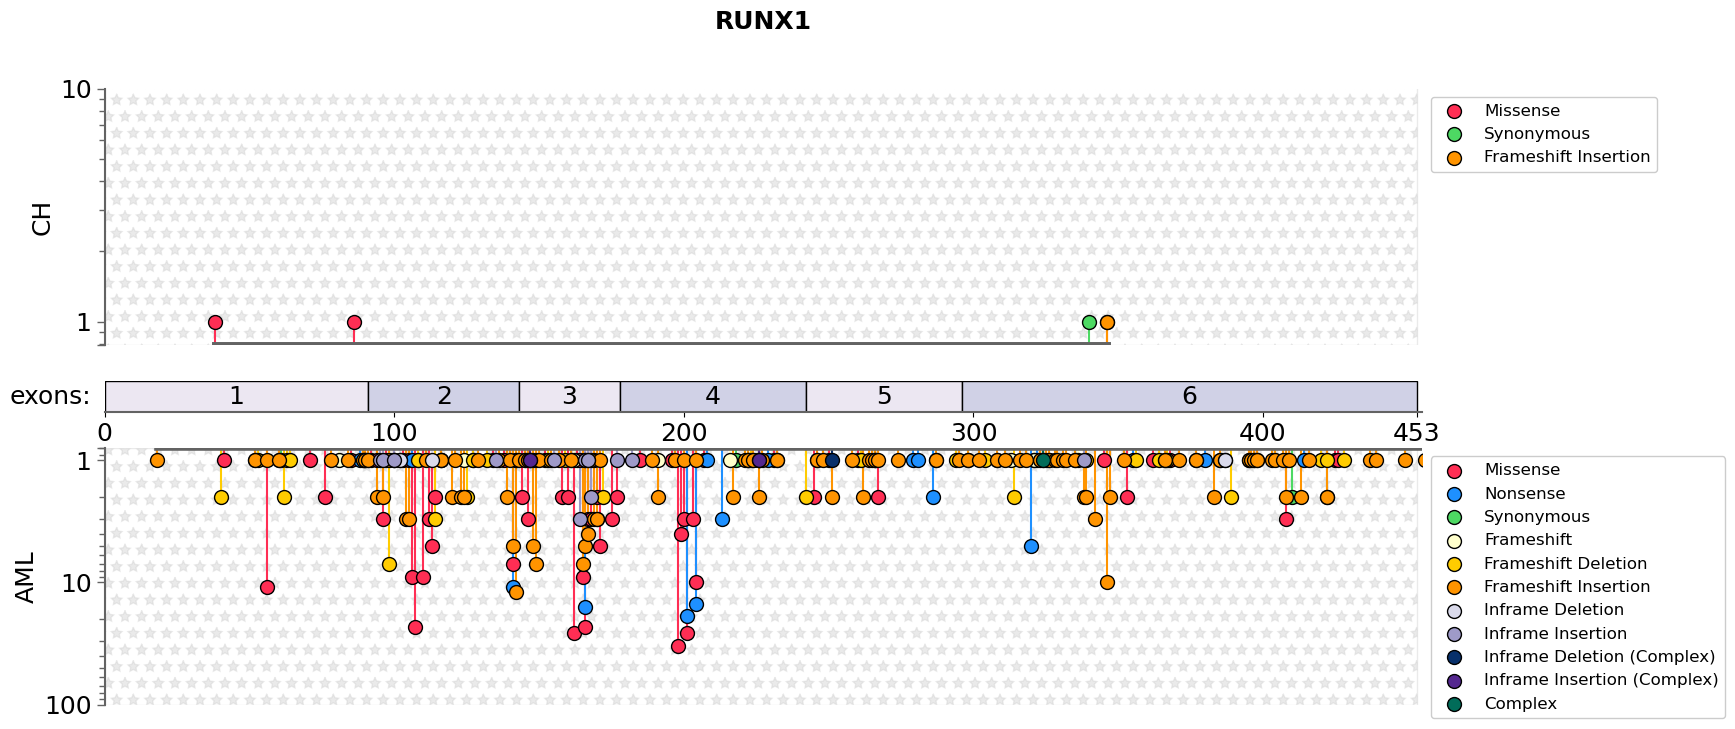

In [38]:
gene = 'RUNX1'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e1
AML_ymax = 1e2
CH_yticks = [10**-0.1, 10**0, 10**1]
CH_ytick_labels = ["0", "1", "10"]
AML_yticks = [10**-0.1, 10**0, 10, 100]
AML_ytick_labels = ["0", "1", "10", "100"]
illumina_panel_position = [(0, 453)]
twist_panel_position = [(0, 453)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# SFB31

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


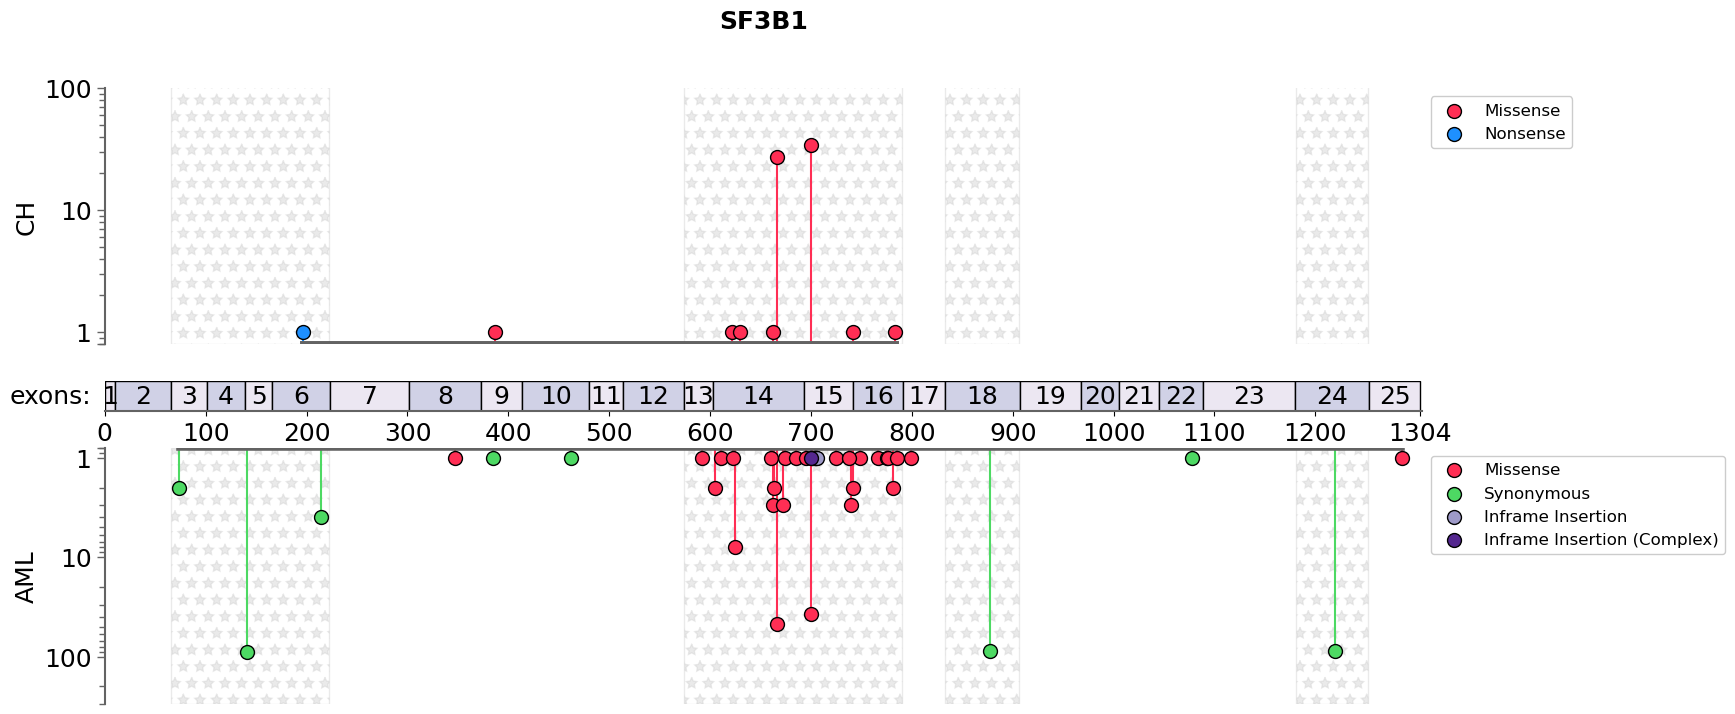

In [39]:
gene = 'SF3B1'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e2
AML_ymax = 3e2
CH_yticks = [10**-0.1, 10**0, 10**1, 1e2]
CH_ytick_labels = ["0", "1", "10", "100"]
AML_yticks = [10**-0.1, 10**0, 10**1, 10**2]
AML_ytick_labels = ["0", "1", "10", "100"]
illumina_panel_position = [(574, 790)]
twist_panel_position = [(66, 222), (574, 790), (833, 906), (1181, 1252)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# SRSF2

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


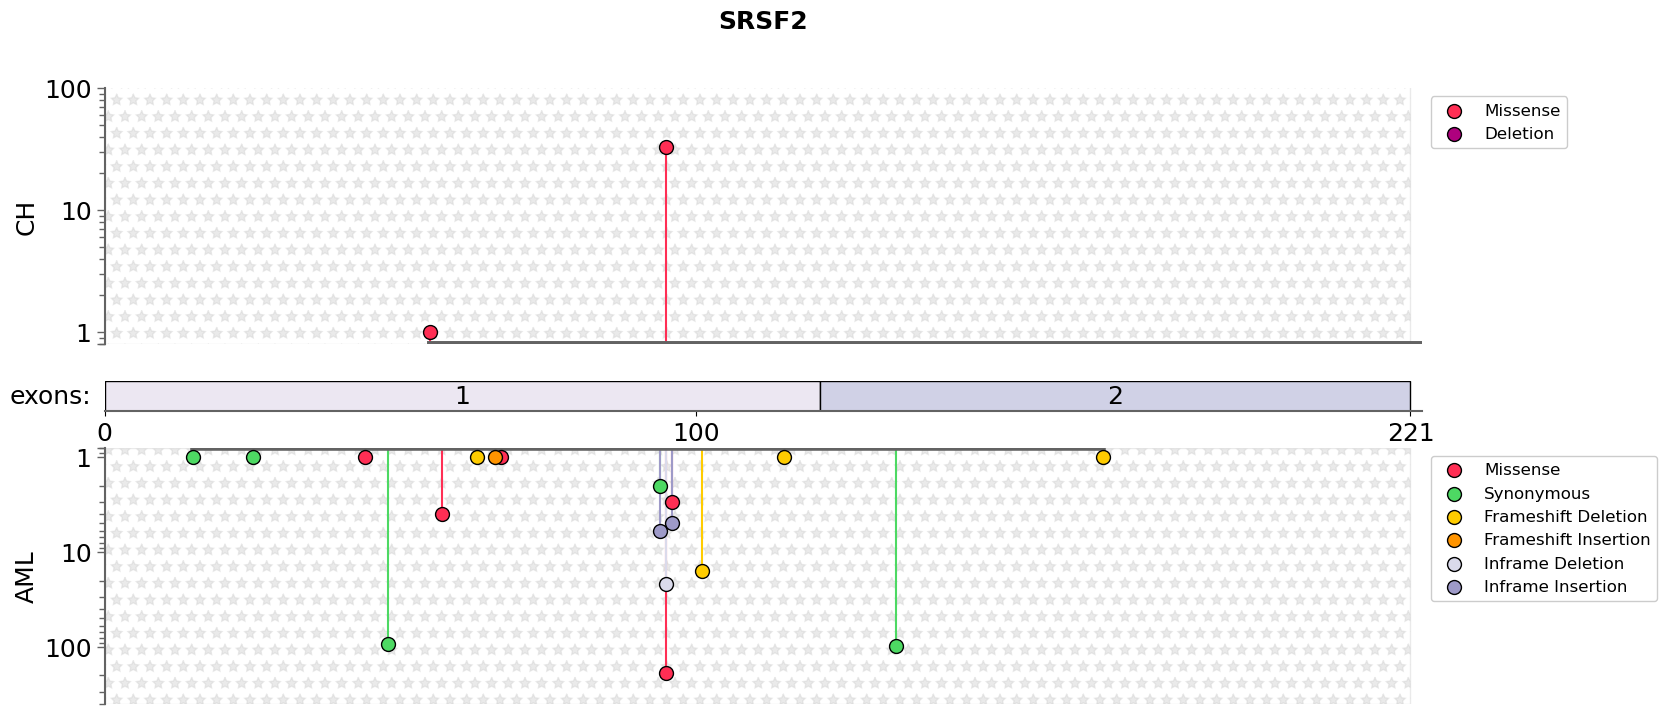

In [40]:
gene = 'SRSF2'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e2
AML_ymax = 4e2
CH_yticks = [10**-0.1, 10**0, 10**1, 1e2]
CH_ytick_labels = ["0", "1", "10", "100"]
AML_yticks = [10**-0.1, 10**0, 10**1, 10**2]
AML_ytick_labels = ["0", "1", "10", "100"]
illumina_panel_position = [(0, 121)]
twist_panel_position = [(0, 221)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# STAG2

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


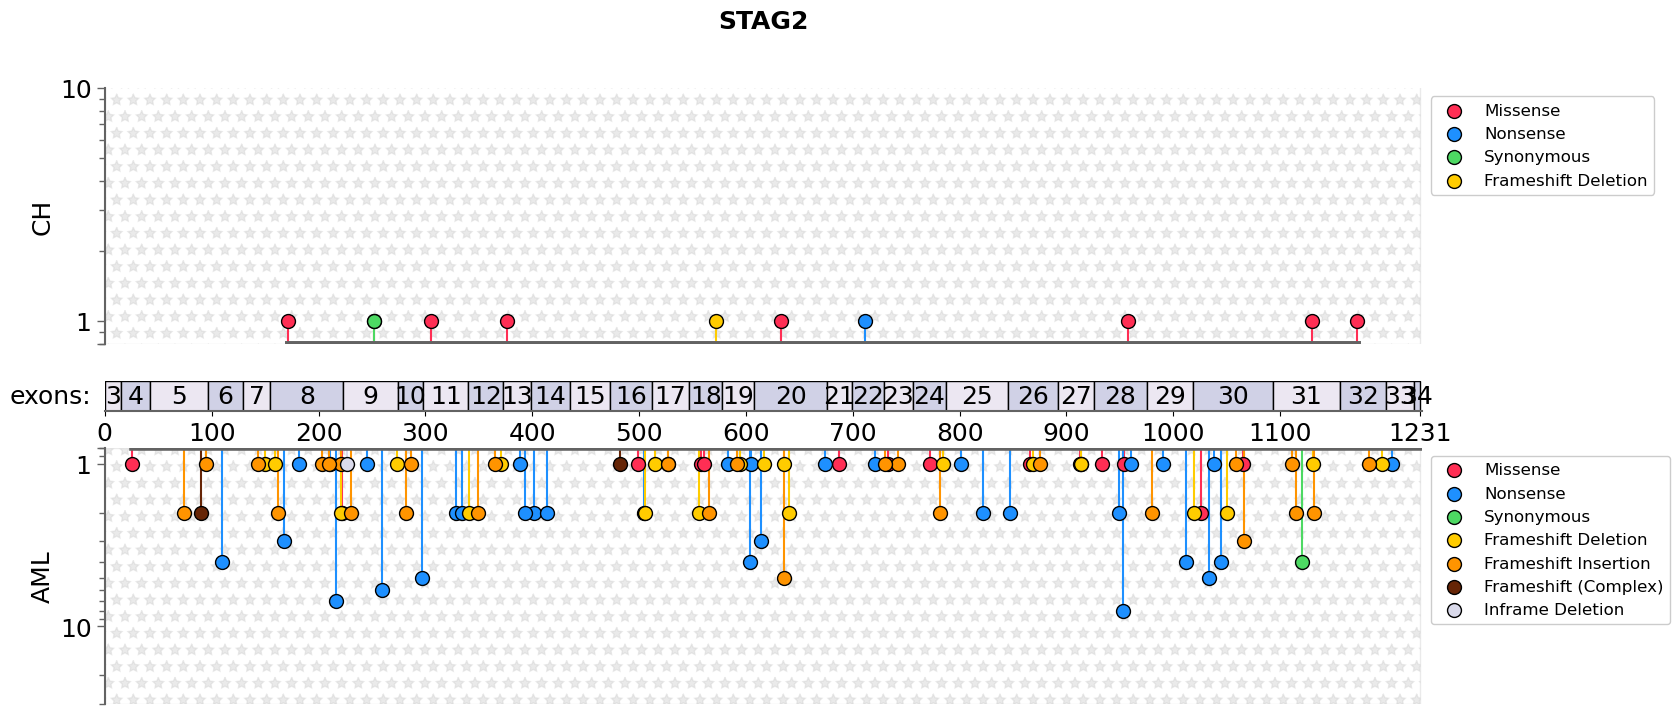

In [41]:
gene = 'STAG2'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e1
AML_ymax = 3e1
CH_yticks = [10**-0.1, 10**0, 10**1]
CH_ytick_labels = ["0", "1", "10"]
AML_yticks = [10**-0.1, 10**0, 10]
AML_ytick_labels = ["0", "1", "10"]
illumina_panel_position = [(0, 1231)]
twist_panel_position = [(0, 1231)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# TET2

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


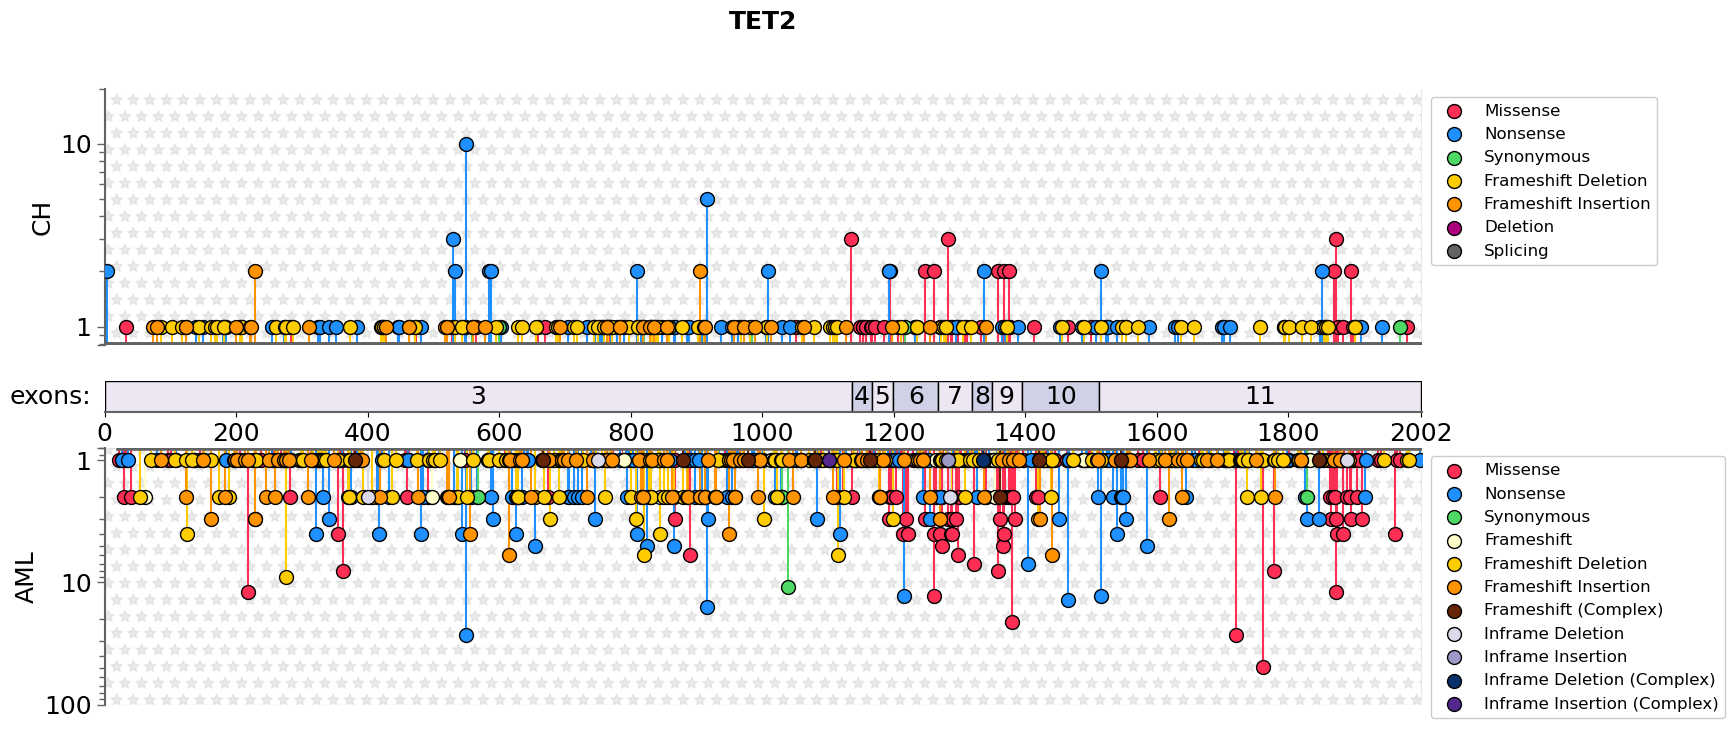

In [42]:
gene = 'TET2'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 2e1
AML_ymax = 1e2
CH_yticks = [10**-0.1, 10**0, 10**1]
CH_ytick_labels = ["0", "1", "10"]
AML_yticks = [10**-0.1, 10**0, 10**1, 10**2]
AML_ytick_labels = ["0", "1", "10", "100"]
illumina_panel_position = [(0, 2002)]
twist_panel_position = [(0, 2002)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# TP53

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


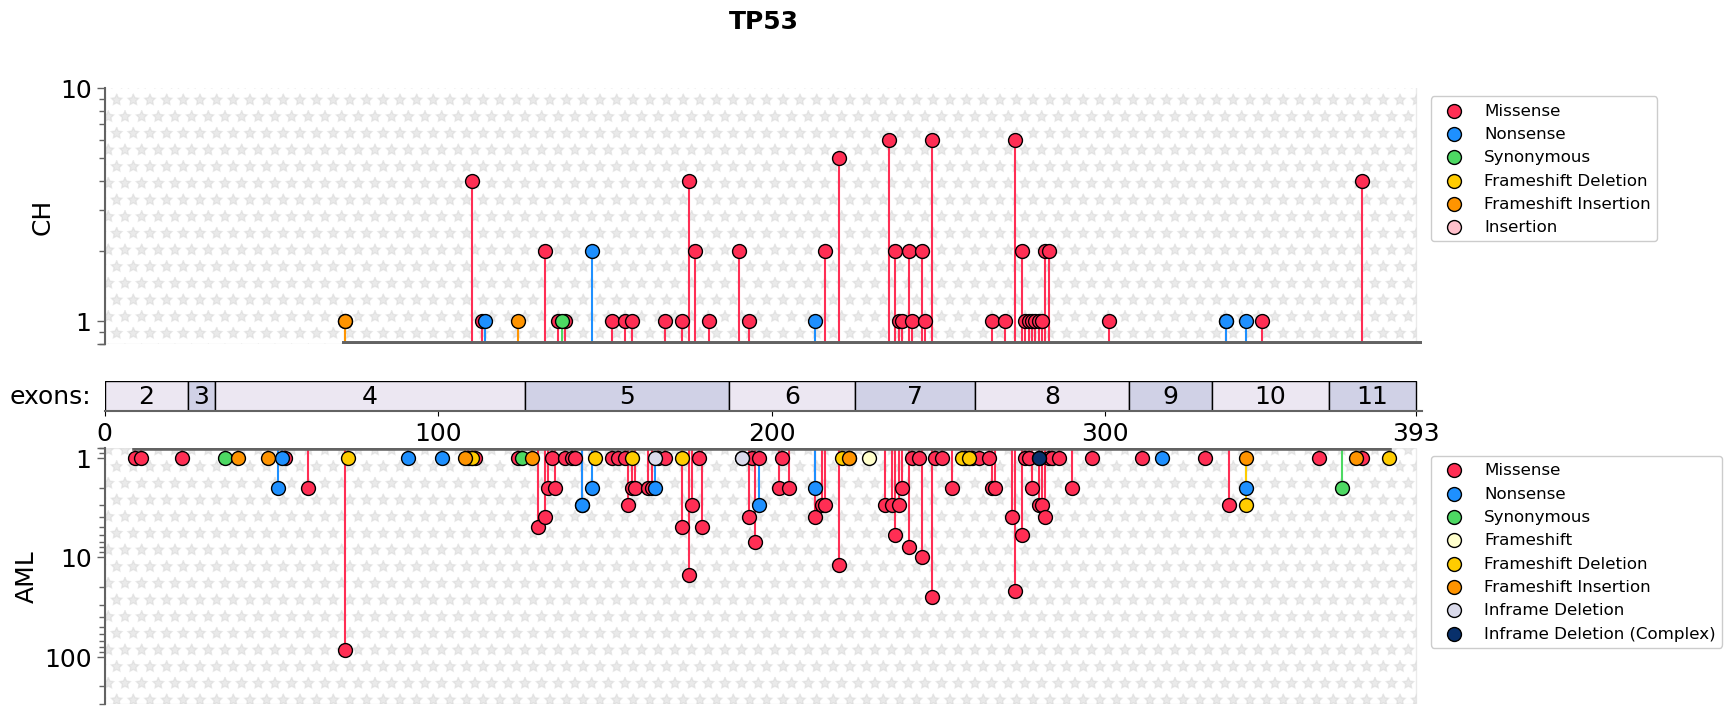

In [43]:
gene = 'TP53'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e1
AML_ymax = 3e2
CH_yticks = [10**-0.1, 10**0, 10**1]
CH_ytick_labels = ["0", "1", "10"]
AML_yticks = [10**-0.1, 10**0, 10**1, 10**2]
AML_ytick_labels = ["0", "1", "10", "100"]
illumina_panel_position = [(0, 393)]
twist_panel_position = [(0, 393)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# U2AF1

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


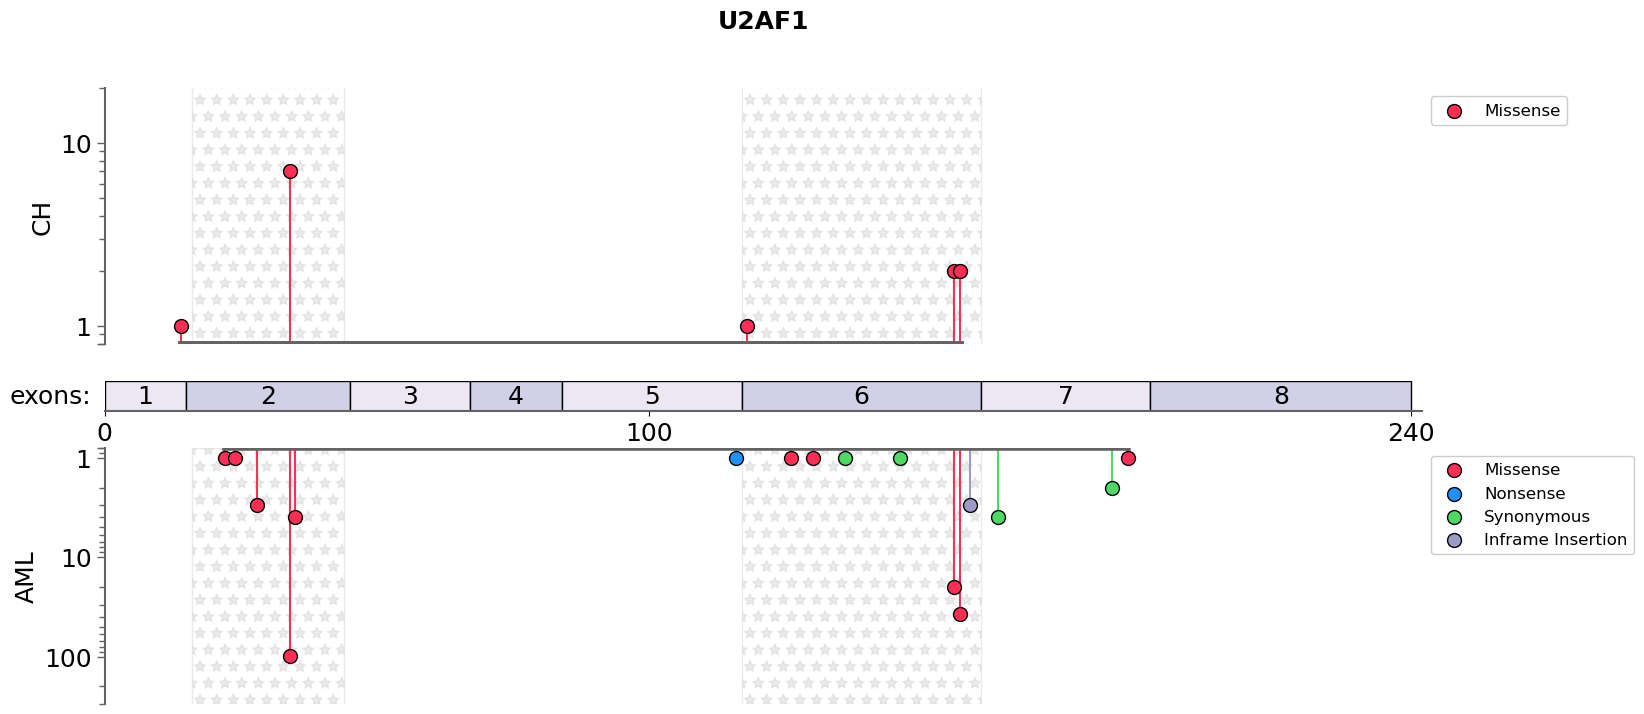

In [44]:
gene = 'U2AF1'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 2e1
AML_ymax = 3e2
CH_yticks = [10**-0.1, 10**0, 10**1]
CH_ytick_labels = ["0", "1", "10"]
AML_yticks = [10**-0.1, 10**0, 10, 100]
AML_ytick_labels = ["0", "1", "10", "100"]
illumina_panel_position = [(16, 44), (117, 161)]
twist_panel_position = [(16, 44), (117, 161)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# WT1

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


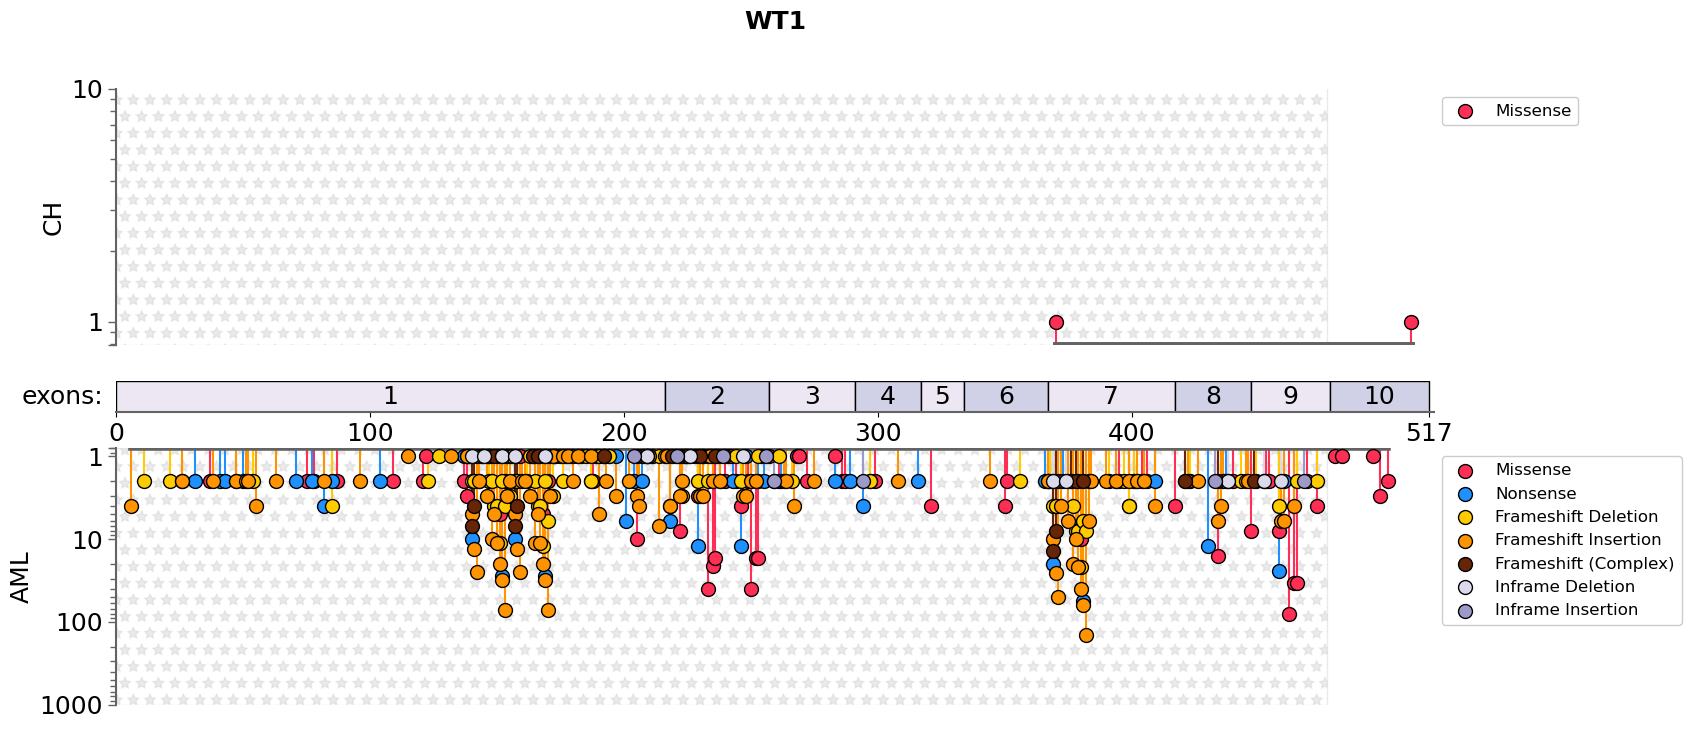

In [45]:
gene = 'WT1'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e1
AML_ymax = 1e3
CH_yticks = [10**-0.1, 10**0, 10**1]
CH_ytick_labels = ["0", "1", "10"]
AML_yticks = [10**-0.1, 10**0, 10, 100, 1000]
AML_ytick_labels = ["0", "1", "10", "100", "1000"]
illumina_panel_position = [(367, 416), (447, 477)]
twist_panel_position = [(0, 477)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')

# ZRSR2

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_16075/470670668.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


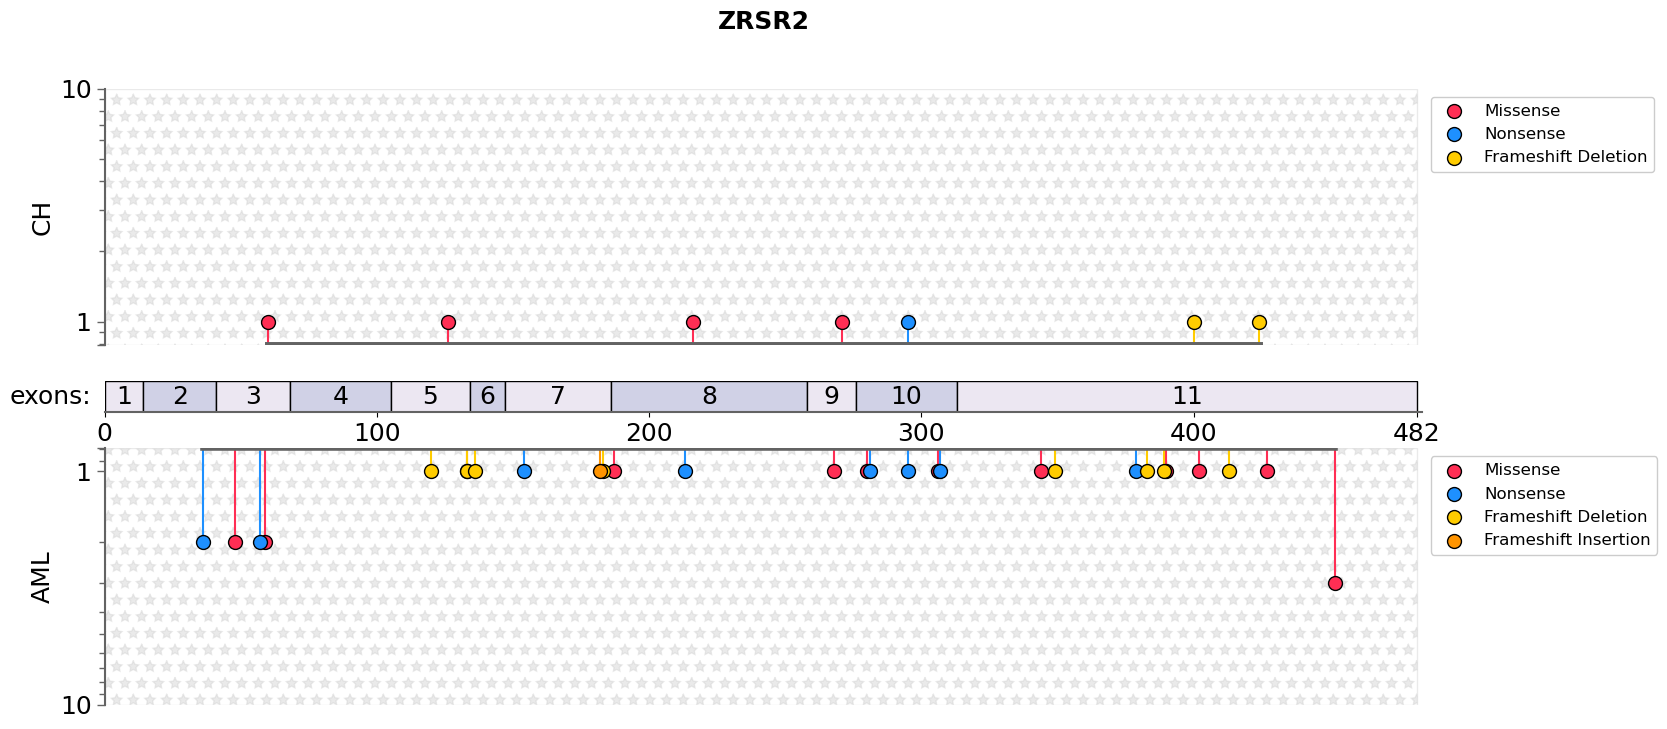

In [46]:
gene = 'ZRSR2'

mutations_CH = CH_mutations_dictionary_combining_variants_at_position(gene)
mutations_AML = AML_mutations_dictionary_combining_variants_at_position(gene, 'Data_files/COSMIC_AML_data/COSMIC_AML_variants_'+gene+'_variant_details.csv')

CH_ymax = 1e1
AML_ymax = 1e1
CH_yticks = [10**-0.1, 10**0, 10**1]
CH_ytick_labels = ["0", "1", "10"]
AML_yticks = [10**-0.1, 10**0, 10]
AML_ytick_labels = ["0", "1", "10"]
illumina_panel_position = [(0, 482)]
twist_panel_position = [(0, 482)]

lollipop_plot(gene, mutations_CH, mutations_AML, CH_ymax, AML_ymax, CH_yticks, CH_ytick_labels, AML_yticks, AML_ytick_labels, illumina_panel_position, twist_panel_position, genome_version='hg19')